In [82]:
#Barış yılmaz 090210343 -- Enes Çağatay Demir 090210314 -- Term Project Data Science
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2

db_config = {
    "host": "localhost",
    "port": "5432",
    "user": "postgres",
    "password": "12345", 
    "dbname": "term_project_db"
}

def get_data_from_db():
    try:
        conn = psycopg2.connect(**db_config)
        query = "SELECT * FROM stock_prices ORDER BY ticker, date"
        
        df = pd.read_sql(query, conn)
        conn.close()
        return df
    except Exception as e:
        print(f"Hata: {e}")
        return None


print("Veriler veritabanından çekiliyor...")
df = get_data_from_db()


if df is not None:
    print(f"Toplam Satır Sayısı: {df.shape[0]}")
    print(f"Toplam Sütun Sayısı: {df.shape[1]}")
    
    
    df['date'] = pd.to_datetime(df['date'])
    

    display(df.head())
    

    print("\nVeri Tipleri:")
    print(df.info())
else:
    print("Veri çekilemedi.")

Veriler veritabanından çekiliyor...
Toplam Satır Sayısı: 33187
Toplam Sütun Sayısı: 8


C:\Users\Barış\AppData\Local\Temp\ipykernel_19476\3547390661.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,date,open_price,high_price,low_price,close_price,adj_close,volume,ticker
0,2014-01-02,16572.169922,16573.070312,16416.490234,16441.349609,16441.349609,80960000,^DJI
1,2014-01-03,16456.890625,16518.740234,16439.300781,16469.990234,16469.990234,72770000,^DJI
2,2014-01-06,16474.039062,16532.990234,16405.519531,16425.099609,16425.099609,89380000,^DJI
3,2014-01-07,16429.019531,16562.320312,16429.019531,16530.939453,16530.939453,81270000,^DJI
4,2014-01-08,16527.660156,16528.880859,16416.689453,16462.740234,16462.740234,103260000,^DJI



Veri Tipleri:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33187 entries, 0 to 33186
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         33187 non-null  datetime64[ns]
 1   open_price   33187 non-null  float64       
 2   high_price   33187 non-null  float64       
 3   low_price    33187 non-null  float64       
 4   close_price  33187 non-null  float64       
 5   adj_close    33187 non-null  float64       
 6   volume       33187 non-null  int64         
 7   ticker       33187 non-null  object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 2.0+ MB
None


In [ ]:
#Barış yılmaz 090210343 -- Enes Çağatay Demir 090210314 -- Term Project Data Science

In [83]:

desc_stats = df.groupby('ticker')['close_price'].describe()

# Okunabilirliği artırmak için virgülden sonra 2 basamak gösterelim
pd.options.display.float_format = '{:.2f}'.format

print("Hisse Bazlı İstatistiksel Özet:")
display(desc_stats)

Hisse Bazlı İstatistiksel Özet:


,count,mean,std,min,25%,50%,75%,max
ticker,,,,,,,,
AAPL,3017.00,98.72,74.79,0.00,28.80,64.08,163.02,286.19
AMZN,3017.00,103.46,64.60,0.00,40.81,94.33,159.84,254.00
AVGO,3017.00,58.72,77.25,0.00,13.85,25.36,56.72,412.18
META,3017.00,244.13,174.27,0.00,123.51,181.51,306.73,788.82
MSFT,3017.00,191.20,144.76,0.00,56.30,144.04,293.21,541.06
NQ=F,3017.00,10555.73,5993.22,0.00,4943.50,8316.00,14846.50,26262.50
NVDA,3017.00,29.81,48.16,0.00,2.43,6.41,26.44,207.03
RTY=F,3017.00,1310.48,886.99,0.00,0.00,1591.10,2006.80,2593.20
TSLA,3017.00,126.52,129.06,0.00,16.57,27.04,235.22,489.88


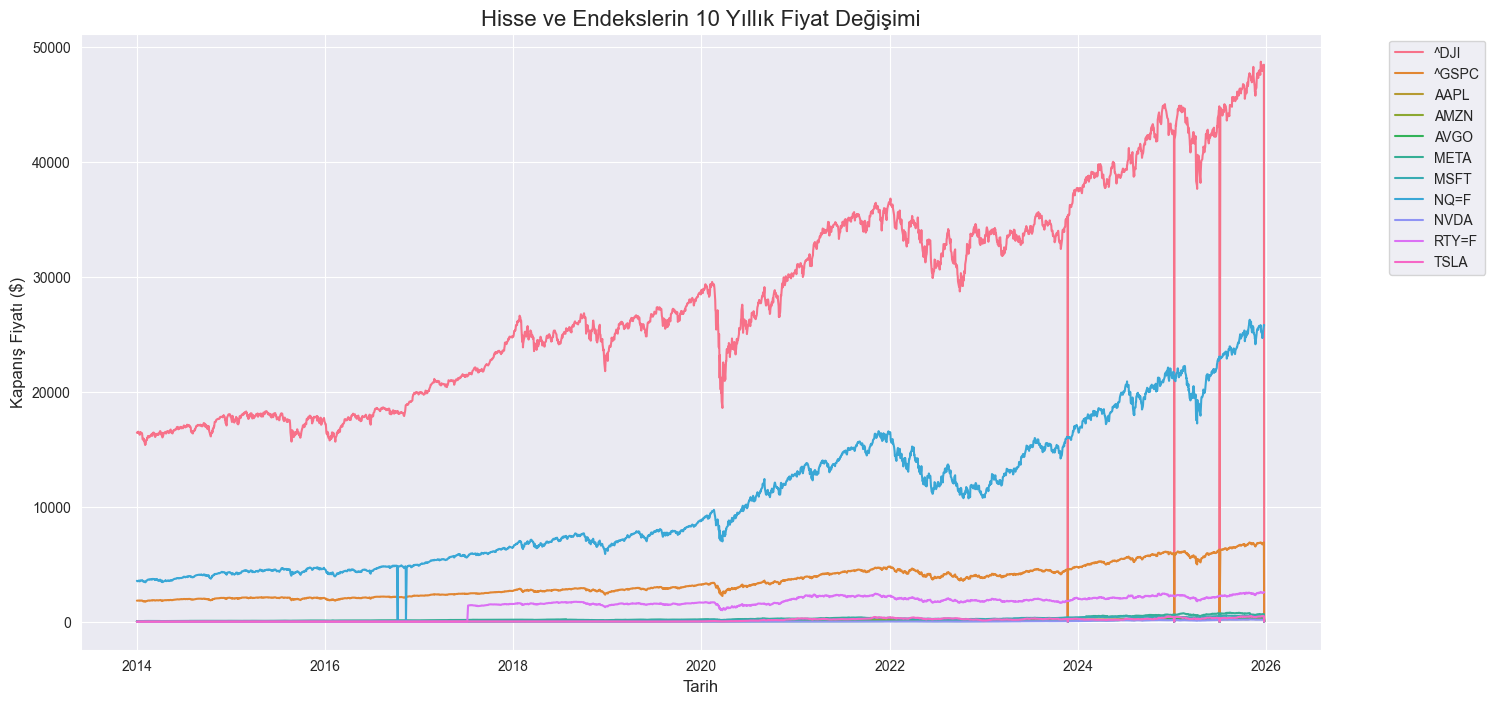

In [84]:

plt.figure(figsize=(16, 8))

# Seaborn ile çizgi grafiği (Hisseleri renklere ayırarak - hue)
sns.lineplot(data=df, x='date', y='close_price', hue='ticker')

plt.title('Hisse ve Endekslerin 10 Yıllık Fiyat Değişimi', fontsize=16)
plt.xlabel('Tarih', fontsize=12)
plt.ylabel('Kapanış Fiyatı ($)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.grid(True)
plt.show()

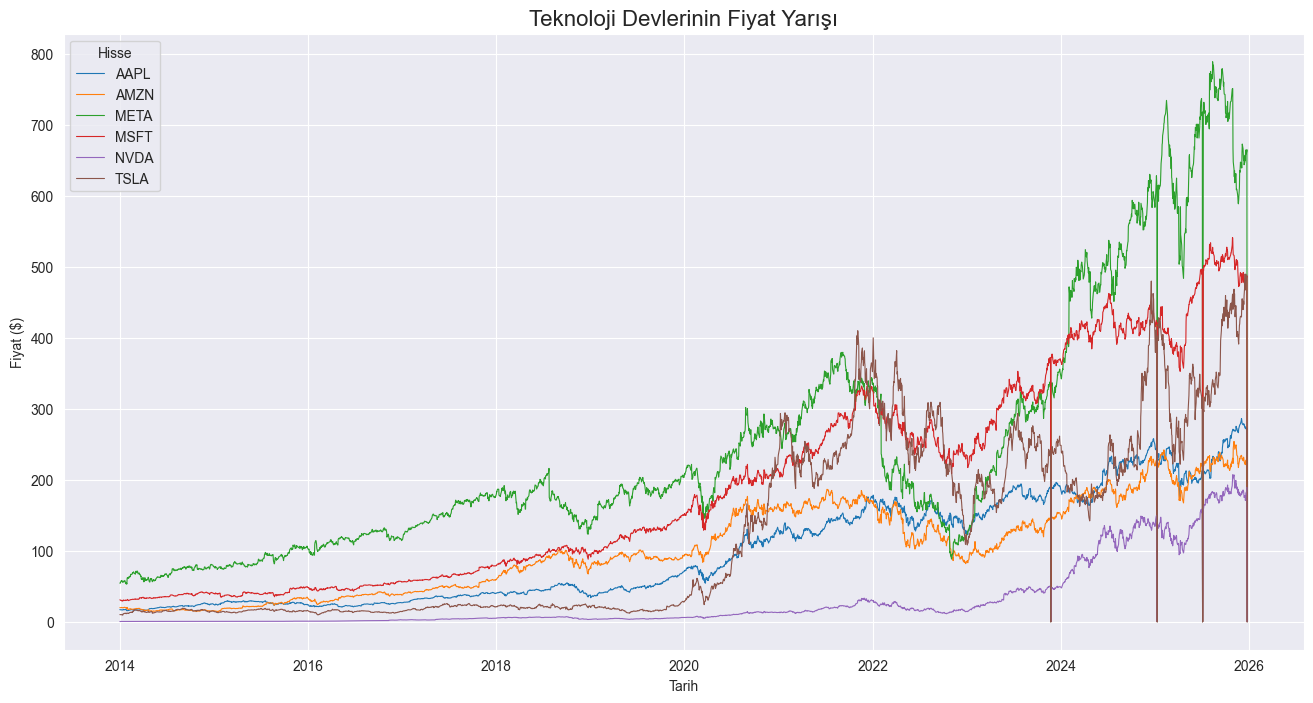

In [86]:
# Sadece belirli hisseleri seçelim (Endeksleri hariç tutuyoruz)
selected_tickers = ['AAPL', 'NVDA', 'MSFT', 'META', 'TSLA', 'AMZN']
tech_stocks = df[df['ticker'].isin(selected_tickers)]

plt.figure(figsize=(16, 8))
sns.lineplot(data=tech_stocks, x='date', y='close_price', hue='ticker', linewidth=0.8)

plt.title('Teknoloji Devlerinin Fiyat Yarışı', fontsize=16)
plt.xlabel('Tarih')
plt.ylabel('Fiyat ($)')
plt.legend(title='Hisse')
plt.grid(True)
plt.show()

In [85]:

print("Boş Değer Sayısı:")
print(df.isnull().sum())

print("\nSıfır (0) Olan Hacim Sayısı:")

print((df['volume'] == 0).sum())

Boş Değer Sayısı:
date           0
open_price     0
high_price     0
low_price      0
close_price    0
adj_close      0
volume         0
ticker         0
dtype: int64

Sıfır (0) Olan Hacim Sayısı:
943


In [87]:

zero_volume_rows = df[df['volume'] == 0]

print("Hacmi 0 Olan Verilerin Dağılımı:")
print(zero_volume_rows.groupby('ticker').size())

print("\nFiyatı da 0 Olan Satır Sayısı:")
print((zero_volume_rows['close_price'] == 0).sum())

Hacmi 0 Olan Verilerin Dağılımı:
ticker
AAPL       4
AMZN       4
AVGO       4
META       4
MSFT       4
NQ=F      12
NVDA       4
RTY=F    894
TSLA       4
^DJI       4
^GSPC      5
dtype: int64

Fiyatı da 0 Olan Satır Sayısı:
923


In [88]:

print(f"Temizlik Öncesi Satır Sayısı: {df.shape[0]}")


df_clean = df[df['close_price'] > 0].copy()


mask_garbage_volume = (~df_clean['ticker'].str.startswith('^')) & (df_clean['volume'] == 0)
df_clean = df_clean[~mask_garbage_volume]

print(f"Temizlik Sonrası Satır Sayısı: {df_clean.shape[0]}")
print(f"Silinen Satır Sayısı: {df.shape[0] - df_clean.shape[0]}")

df = df_clean

Temizlik Öncesi Satır Sayısı: 33187
Temizlik Sonrası Satır Sayısı: 32245
Silinen Satır Sayısı: 942


In [89]:

desc_stats_clean = df.groupby('ticker')['close_price'].describe()

pd.options.display.float_format = '{:.2f}'.format
print("TEMİZLENMİŞ Veri İstatistikleri:")
display(desc_stats_clean)

TEMİZLENMİŞ Veri İstatistikleri:


,count,mean,std,min,25%,50%,75%,max
ticker,,,,,,,,
AAPL,3013.00,98.85,74.76,15.50,28.86,64.25,163.02,286.19
AMZN,3013.00,103.60,64.54,14.35,40.88,94.37,159.90,254.00
AVGO,3013.00,58.80,77.27,3.90,13.90,25.37,56.75,412.18
META,3013.00,244.45,174.16,53.16,124.01,181.64,306.77,788.82
MSFT,3013.00,191.46,144.68,29.02,56.34,144.35,293.50,541.06
NQ=F,3005.00,10545.02,5968.63,3430.00,4956.00,8316.00,14827.75,26262.50
NVDA,3013.00,29.85,48.18,0.36,2.43,6.44,26.44,207.03
RTY=F,2123.00,1853.60,322.62,998.30,1568.80,1821.50,2128.98,2593.20
TSLA,3013.00,126.69,129.07,9.29,16.58,27.89,235.43,489.88


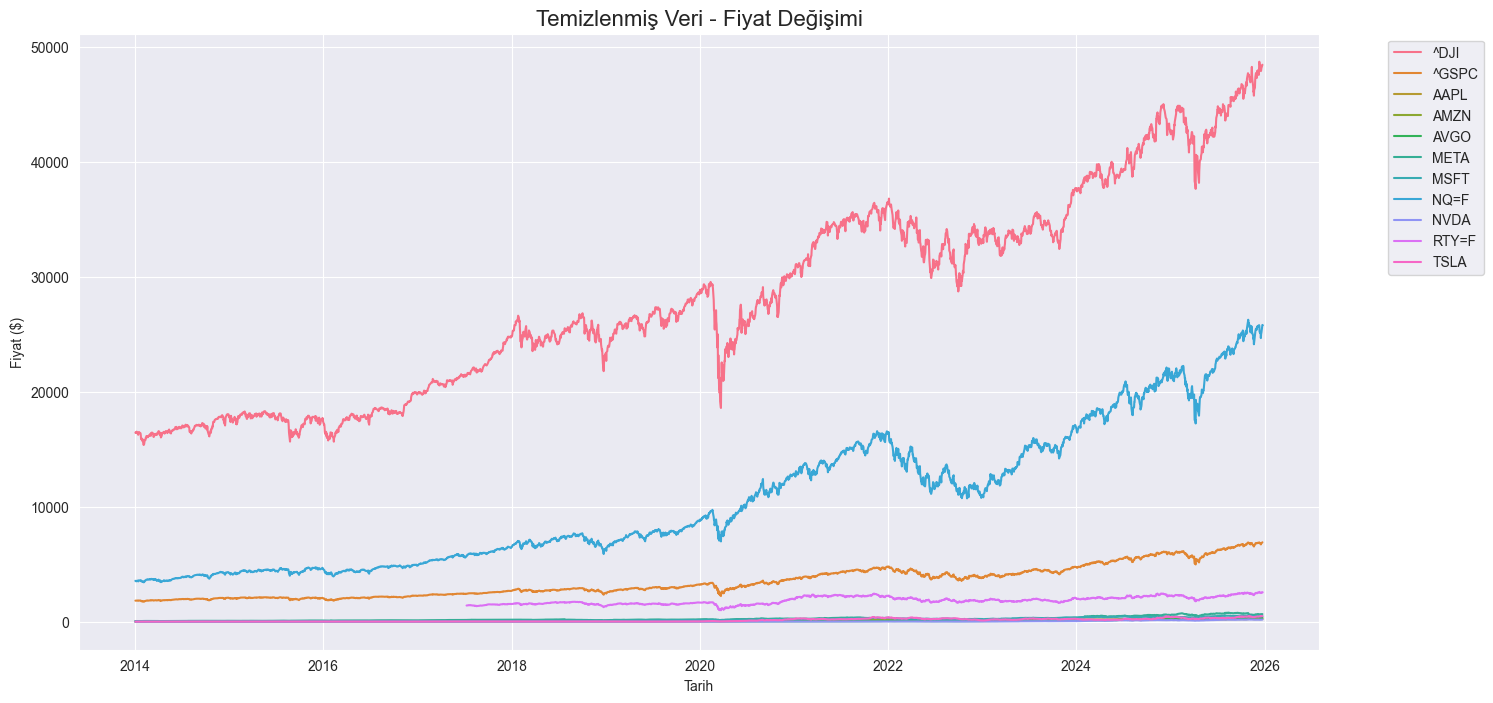

In [90]:

plt.figure(figsize=(16, 8))
sns.lineplot(data=df, x='date', y='close_price', hue='ticker')

plt.title('Temizlenmiş Veri - Fiyat Değişimi', fontsize=16)
plt.xlabel('Tarih')
plt.ylabel('Fiyat ($)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

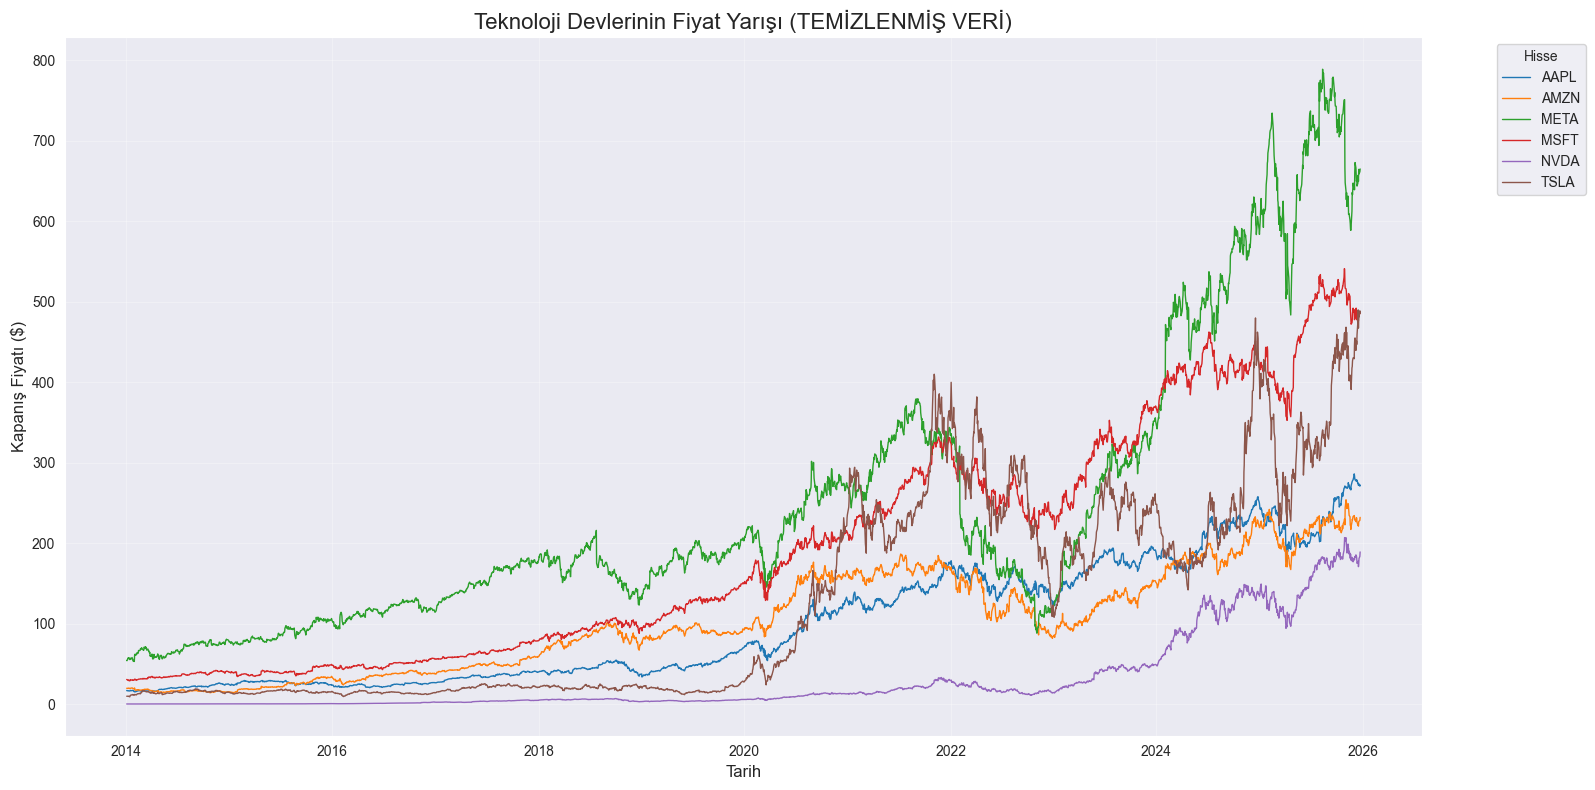

In [91]:

selected_tickers = ['AAPL', 'NVDA', 'MSFT', 'META', 'TSLA', 'AMZN']
tech_stocks = df[df['ticker'].isin(selected_tickers)]


plt.figure(figsize=(16, 8))
sns.lineplot(data=tech_stocks, x='date', y='close_price', hue='ticker', linewidth=1)


plt.title('Teknoloji Devlerinin Fiyat Yarışı (TEMİZLENMİŞ VERİ)', fontsize=16)
plt.xlabel('Tarih', fontsize=12)
plt.ylabel('Kapanış Fiyatı ($)', fontsize=12)
plt.legend(title='Hisse', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

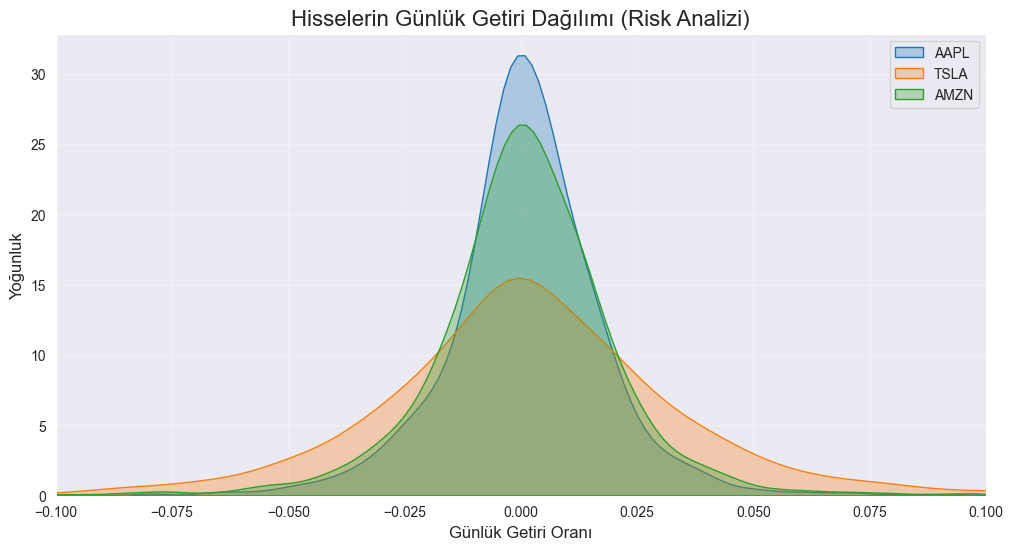

In [92]:

df['Daily_Return'] = df.groupby('ticker')['close_price'].pct_change()


plt.figure(figsize=(12, 6))


subset_tickers = ['AAPL', 'TSLA', 'AMZN']
for ticker in subset_tickers:
    subset = df[df['ticker'] == ticker]
  
    sns.kdeplot(subset['Daily_Return'].dropna(), label=ticker, fill=True, alpha=0.3)

plt.title('Hisselerin Günlük Getiri Dağılımı (Risk Analizi)', fontsize=16)
plt.xlabel('Günlük Getiri Oranı', fontsize=12)
plt.ylabel('Yoğunluk', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(-0.10, 0.10)
plt.show()

C:\Users\Barış\AppData\Local\Temp\ipykernel_19476\3635734235.py:4: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  corr_matrix = pivot_df.pct_change().corr()


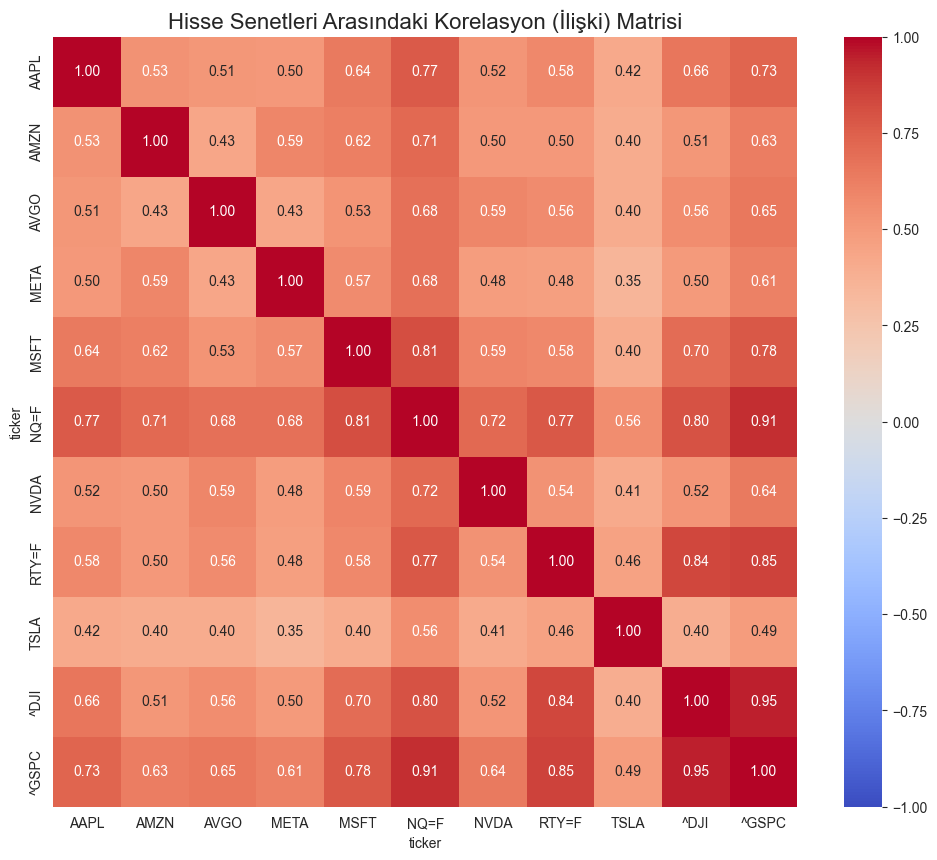

In [93]:

pivot_df = df.pivot_table(index='date', columns='ticker', values='close_price')


corr_matrix = pivot_df.pct_change().corr()


plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Hisse Senetleri Arasındaki Korelasyon (İlişki) Matrisi', fontsize=16)
plt.show()

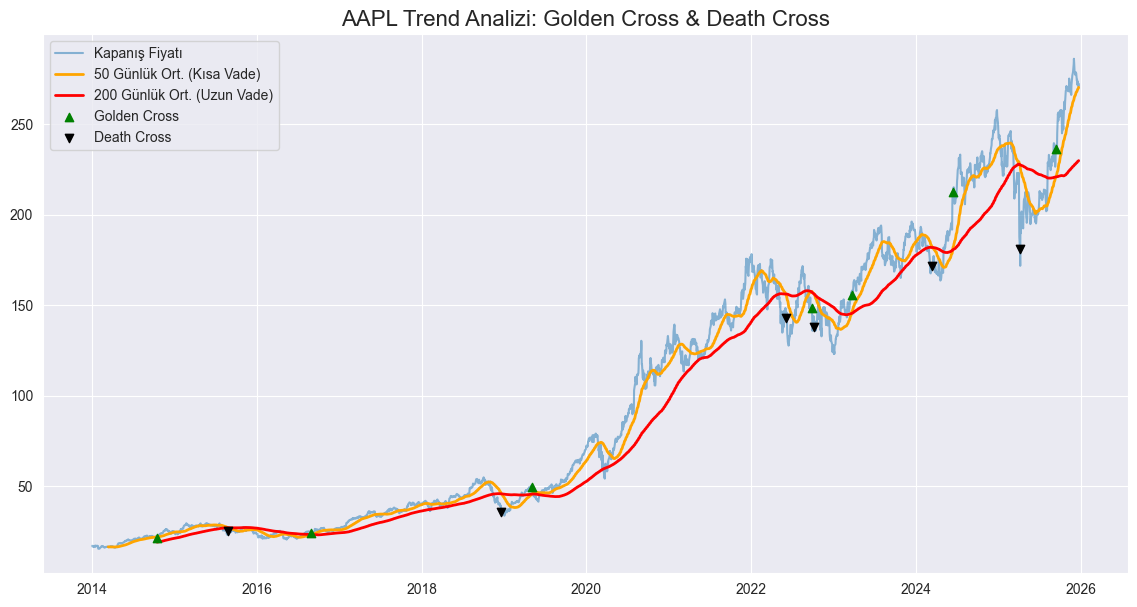

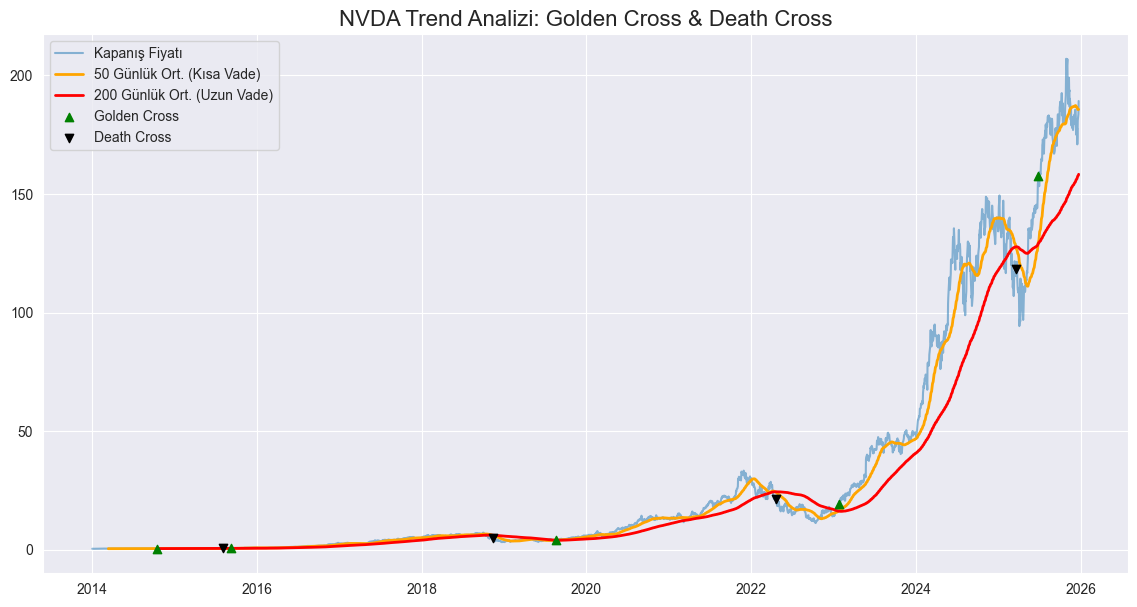

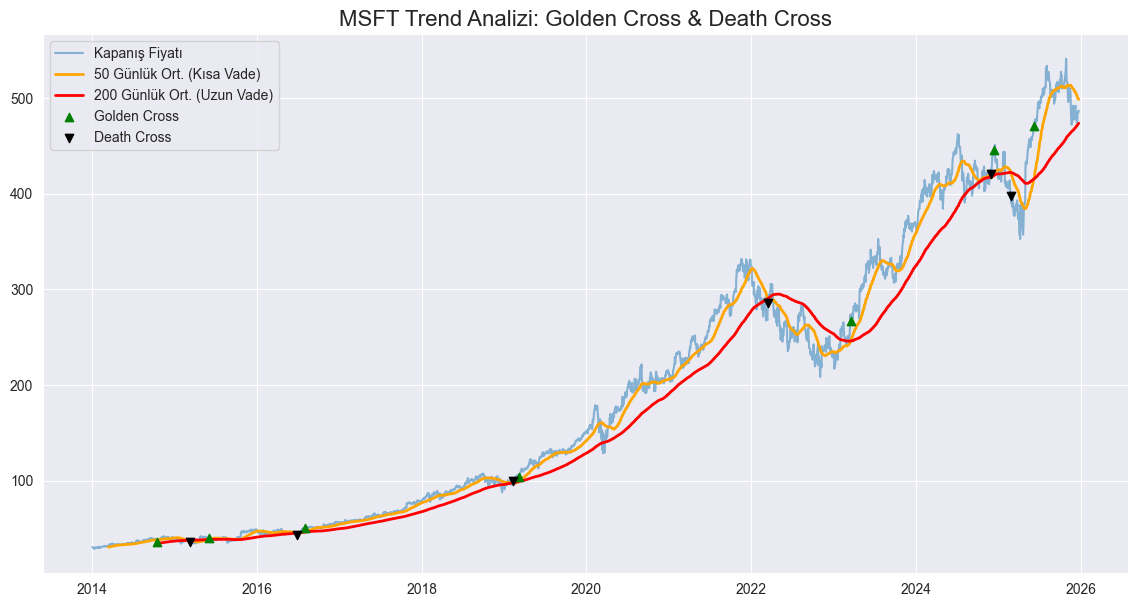

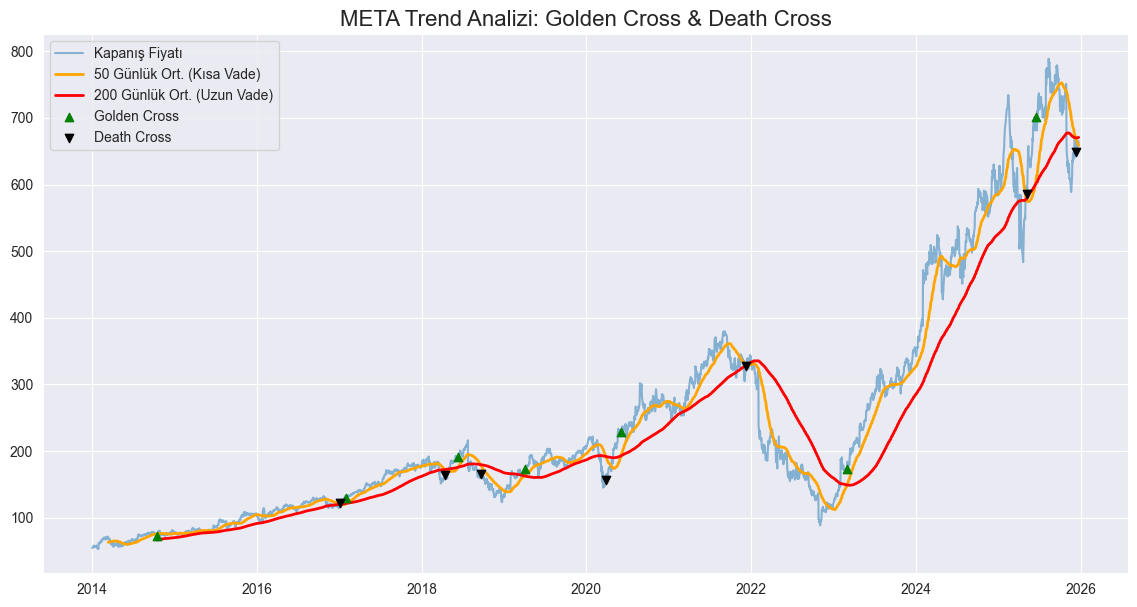

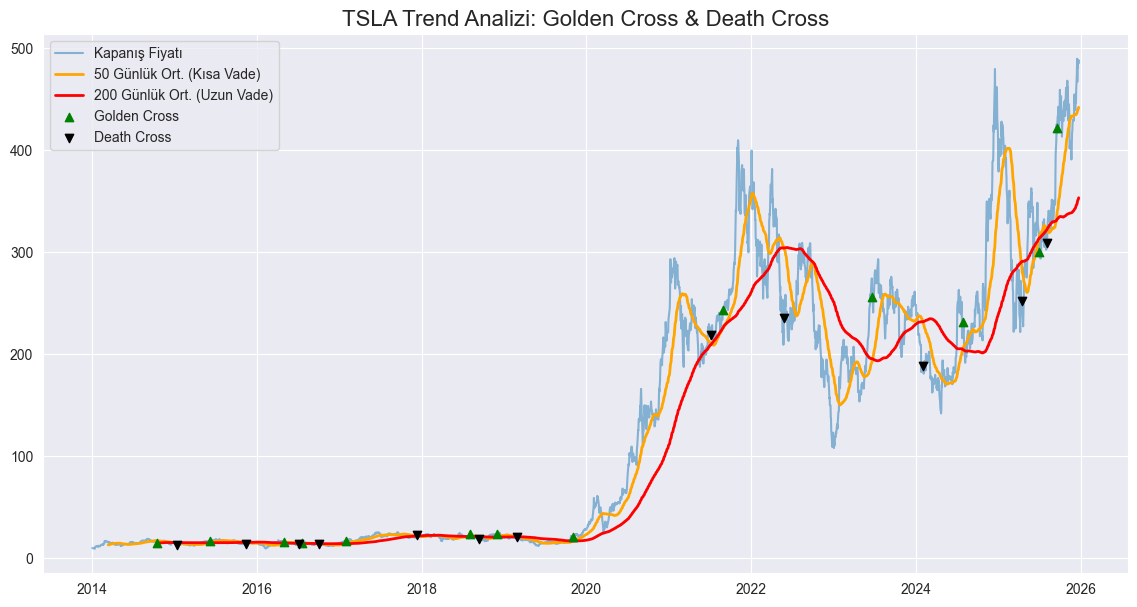

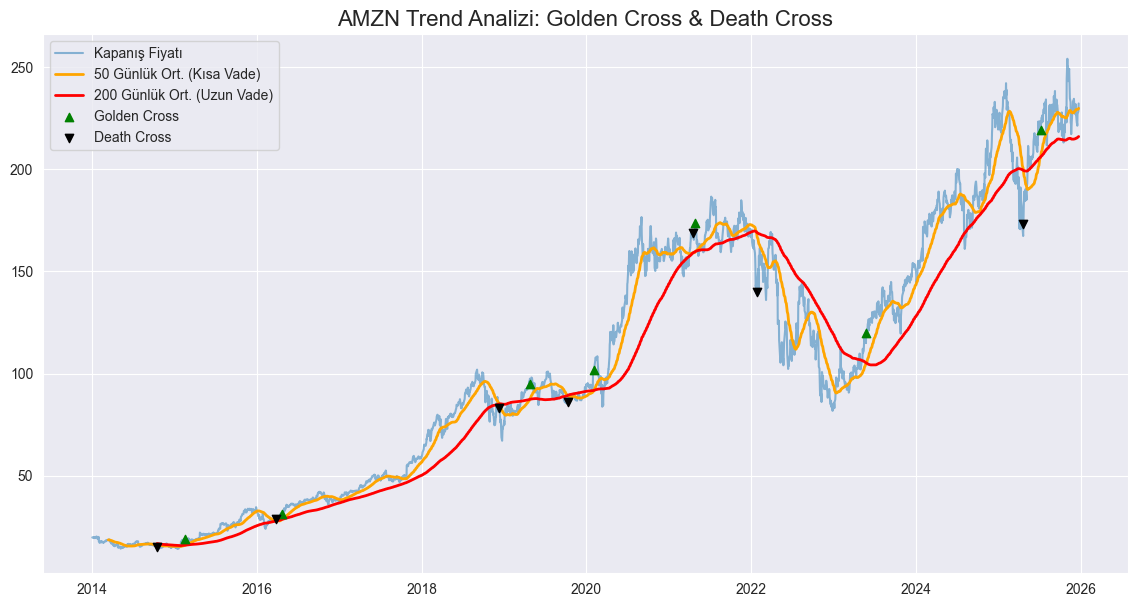

In [94]:

selected_tickers = ['AAPL', 'NVDA', 'MSFT', 'META', 'TSLA', 'AMZN']

for ticker in selected_tickers:
    ticker_df = df[df['ticker'] == ticker].copy().sort_values('date')
    if ticker_df.empty:
        print(f\
)
        continue

   
    ticker_df['SMA_50'] = ticker_df['close_price'].rolling(window=50).mean()
    ticker_df['SMA_200'] = ticker_df['close_price'].rolling(window=200).mean()

    plt.figure(figsize=(14, 7))
    plt.plot(ticker_df['date'], ticker_df['close_price'], label='Kapanış Fiyatı', alpha=0.5)
    plt.plot(ticker_df['date'], ticker_df['SMA_50'], label='50 Günlük Ort. (Kısa Vade)', color='orange', linewidth=2)
    plt.plot(ticker_df['date'], ticker_df['SMA_200'], label='200 Günlük Ort. (Uzun Vade)', color='red', linewidth=2)


    sma_diff = ticker_df['SMA_50'] - ticker_df['SMA_200']
    cross_sign = sma_diff.apply(lambda x: 1 if x>0 else (-1 if x<0 else 0))
    cross_change = cross_sign != cross_sign.shift()
    golden_mask = (sma_diff > 0) & cross_change
    death_mask = (sma_diff < 0) & cross_change

    plt.scatter(ticker_df.loc[golden_mask, 'date'], ticker_df.loc[golden_mask, 'close_price'], marker='^', color='green', label='Golden Cross', zorder=5)
    plt.scatter(ticker_df.loc[death_mask, 'date'], ticker_df.loc[death_mask, 'close_price'], marker='v', color='black', label='Death Cross', zorder=5)

    plt.title(f'{ticker} Trend Analizi: Golden Cross & Death Cross', fontsize=16)
    plt.legend()
    plt.grid(True)
    plt.show()

In [95]:
import numpy as np
import pandas as pd

# GLOBAL SETTING: Show 6 decimal places (No more rounding in display)
pd.options.display.float_format = '{:.6f}'.format

def engineer_features(df):
    
    df = df.copy()
    
    # Sort data by Ticker and Date (Crucial for correct rolling calculations)
    df = df.sort_values(['ticker', 'date'])

 
    
    # A. Moving Averages (Trend)
    df['SMA_10'] = df.groupby('ticker')['close_price'].transform(lambda x: x.rolling(window=10).mean())
    df['SMA_50'] = df.groupby('ticker')['close_price'].transform(lambda x: x.rolling(window=50).mean())
    
    # B. RSI (Relative Strength Index)
    def compute_rsi(series, window=14):
        delta = series.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
        rs = gain / loss
        return 100 - (100 / (1 + rs))
    
    df['RSI'] = df.groupby('ticker')['close_price'].transform(lambda x: compute_rsi(x))
    
    # C. MACD
    df['EMA_12'] = df.groupby('ticker')['close_price'].transform(lambda x: x.ewm(span=12, adjust=False).mean())
    df['EMA_26'] = df.groupby('ticker')['close_price'].transform(lambda x: x.ewm(span=26, adjust=False).mean())
    df['MACD'] = df['EMA_12'] - df['EMA_26']
    df['MACD_Signal'] = df.groupby('ticker')['MACD'].transform(lambda x: x.ewm(span=9, adjust=False).mean())
    
    # D. Bollinger Bands (Risk Metrics)
    df['Bollinger_Middle'] = df.groupby('ticker')['close_price'].transform(lambda x: x.rolling(window=20).mean())
    df['Bollinger_Std'] = df.groupby('ticker')['close_price'].transform(lambda x: x.rolling(window=20).std())
    df['Bollinger_Upper'] = df['Bollinger_Middle'] + (df['Bollinger_Std'] * 2)
    df['Bollinger_Lower'] = df['Bollinger_Middle'] - (df['Bollinger_Std'] * 2)
    

    
    # A. Lag Features (Delayed Prices)
    df['Lag_1'] = df.groupby('ticker')['close_price'].shift(1) # Yesterday
    df['Lag_2'] = df.groupby('ticker')['close_price'].shift(2)
    df['Lag_5'] = df.groupby('ticker')['close_price'].shift(5)
    

    # Calculating the absolute difference in price (Today - Yesterday)
    df['Price_Change'] = df['close_price'] - df['Lag_1']
    
    # C. Daily Return (Percentage)
    df['Daily_Return'] = df.groupby('ticker')['close_price'].pct_change()
    
    # D. Historical/Seasonal Features
    df['Month'] = df['date'].dt.month
    df['DayOfWeek'] = df['date'].dt.dayofweek
    
 
    # Will the price go UP tomorrow? (1: Yes, 0: No)
    df['Next_Close'] = df.groupby('ticker')['close_price'].shift(-1)
    df['Target'] = (df['Next_Close'] > df['close_price']).astype(int)
    
    # Drop NaN values
    df_engineered = df.dropna()
    
    print("✅ Feature Engineering Completed!")
    return df_engineered

# Execute the function
df_final = engineer_features(df)

# Check the results (Showing the requested columns)
print(f"\nNew Data Shape: {df_final.shape}")
print("New Column 'Price_Change' has been added.")

# Display relevant columns to verify
display(df_final[['date', 'ticker', 'close_price', 'Lag_1', 'Price_Change', 'Daily_Return']].head(10))

✅ Feature Engineering Completed!

New Data Shape: (31695, 28)
New Column 'Price_Change' has been added.


,date,ticker,close_price,Lag_1,Price_Change,Daily_Return
6083,2014-03-14,AAPL,16.371983,16.557957,-0.185974,-0.011232
6084,2014-03-17,AAPL,16.435946,16.371983,0.063963,0.003907
6085,2014-03-18,AAPL,16.581348,16.435946,0.145403,0.008847
6086,2014-03-19,AAPL,16.576986,16.581348,-0.004362,-0.000263
6087,2014-03-20,AAPL,16.497110,16.576986,-0.079876,-0.004818
6088,2014-03-21,AAPL,16.627222,16.497110,0.130112,0.007887
6089,2014-03-24,AAPL,16.824425,16.627222,0.197203,0.011860
6090,2014-03-25,AAPL,17.005404,16.824425,0.180979,0.010757
6091,2014-03-26,AAPL,16.842834,17.005404,-0.162569,-0.009560
6092,2014-03-27,AAPL,16.770447,16.842834,-0.072388,-0.004298


In [96]:
display(df_final.head(50))

,date,open_price,high_price,low_price,close_price,adj_close,volume,ticker,Daily_Return,SMA_10,...,Bollinger_Upper,Bollinger_Lower,Lag_1,Lag_2,Lag_5,Price_Change,Month,DayOfWeek,Next_Close,Target
6083,2014-03-14,16.499914,16.565442,16.319248,16.371983,16.371983,237199200,AAPL,-0.011232,16.573586,...,16.989557,16.136114,16.557957,16.743919,16.551399,-0.185974,3,4,16.435946,1
6084,2014-03-17,16.465901,16.536731,16.408174,16.435946,16.435946,199544800,AAPL,0.003907,16.570403,...,16.919076,16.152770,16.371983,16.557957,16.566383,0.063963,3,0,16.581348,1
6085,2014-03-18,16.409731,16.599134,16.387890,16.581348,16.581348,209647200,AAPL,0.008847,16.570902,...,16.816940,16.209380,16.435946,16.371983,16.727697,0.145403,3,1,16.576986,0
6086,2014-03-19,16.608190,16.732377,16.506466,16.576986,16.576986,224756000,AAPL,-0.000263,16.567469,...,16.784917,16.222338,16.581348,16.435946,16.743919,-0.004362,3,2,16.497110,0
6087,2014-03-20,16.534242,16.620988,16.454986,16.497110,16.497110,208398400,AAPL,-0.004818,16.561073,...,16.779165,16.220445,16.576986,16.581348,16.557957,-0.079876,3,3,16.627222,1
6088,2014-03-21,16.597891,16.654681,16.423155,16.627222,16.627222,374046400,AAPL,0.007887,16.568655,...,16.791517,16.231870,16.497110,16.576986,16.371983,0.130112,3,4,16.824425,1
6089,2014-03-24,16.800398,16.865301,16.695555,16.824425,16.824425,355700800,AAPL,0.011860,16.594459,...,16.841247,16.218460,16.627222,16.497110,16.435946,0.197203,3,0,17.005404,1
6090,2014-03-25,16.896506,17.029118,16.836906,17.005404,17.005404,282293200,AAPL,0.010757,16.622230,...,16.922093,16.209163,16.824425,16.627222,16.581348,0.180979,3,1,16.842834,0
6091,2014-03-26,17.053144,17.130528,16.814129,16.842834,16.842834,299768000,AAPL,-0.009560,16.632121,...,16.917603,16.283642,17.005404,16.824425,16.576986,-0.162569,3,2,16.770447,0
6092,2014-03-27,16.850327,16.896509,16.697432,16.770447,16.770447,222031600,AAPL,-0.004298,16.653370,...,16.934788,16.297004,16.842834,17.005404,16.497110,-0.072388,3,3,16.751724,0


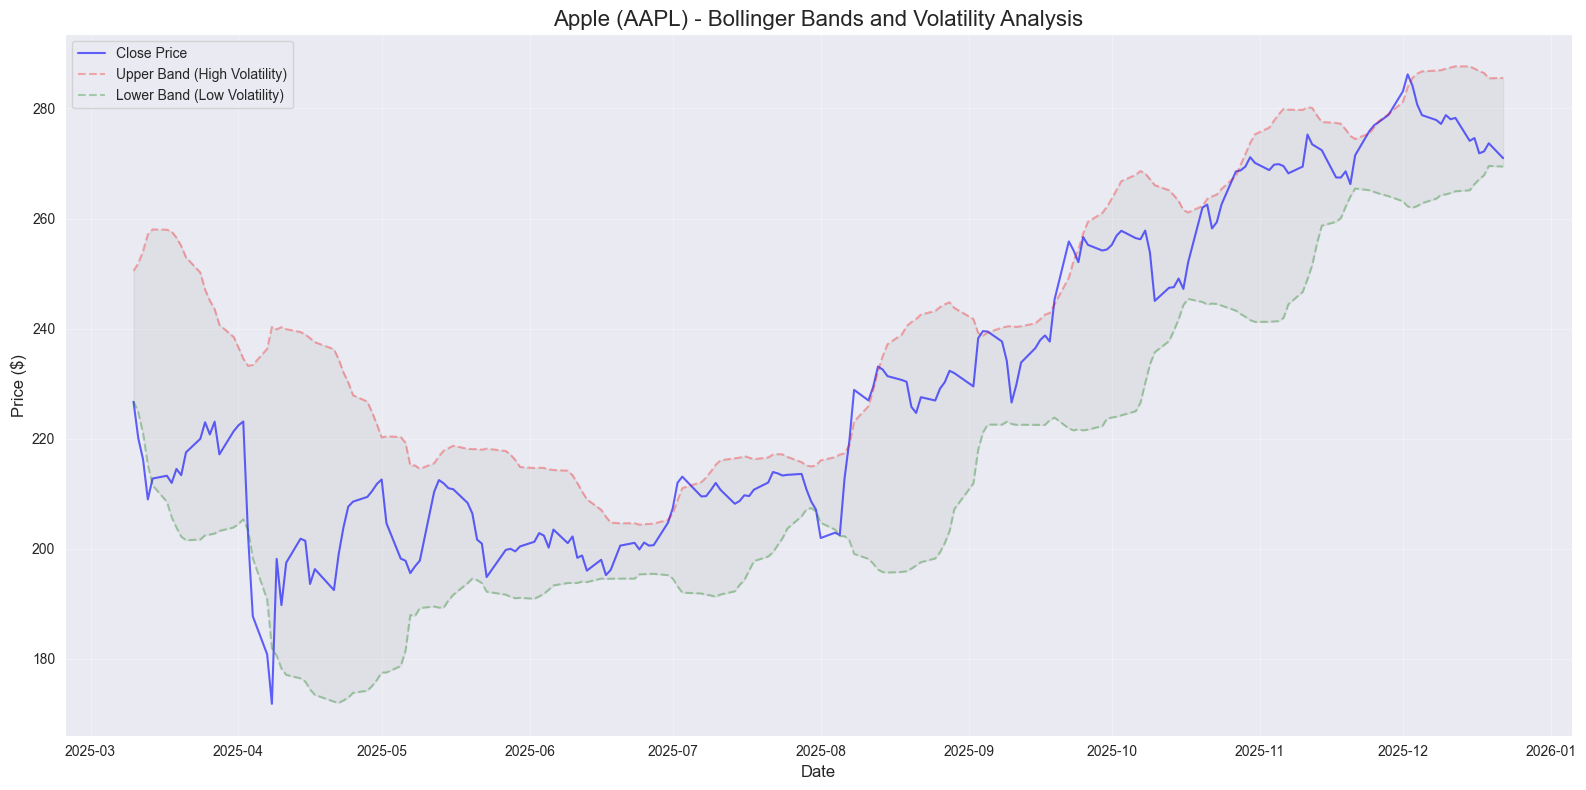

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

subset = df_final[df_final['ticker'] == 'AAPL'][-200:]

plt.figure(figsize=(16, 8))


plt.plot(subset['date'], subset['close_price'], label='Close Price', color='blue', alpha=0.6)

plt.plot(subset['date'], subset['Bollinger_Upper'], label='Upper Band (High Volatility)', color='red', linestyle='--', alpha=0.3)
plt.plot(subset['date'], subset['Bollinger_Lower'], label='Lower Band (Low Volatility)', color='green', linestyle='--', alpha=0.3)


plt.fill_between(subset['date'], subset['Bollinger_Upper'], subset['Bollinger_Lower'], color='gray', alpha=0.1)


plt.title('Apple (AAPL) - Bollinger Bands and Volatility Analysis', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

📊 Generating Bollinger Band plots for: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', '^GSPC', '^DJI']...


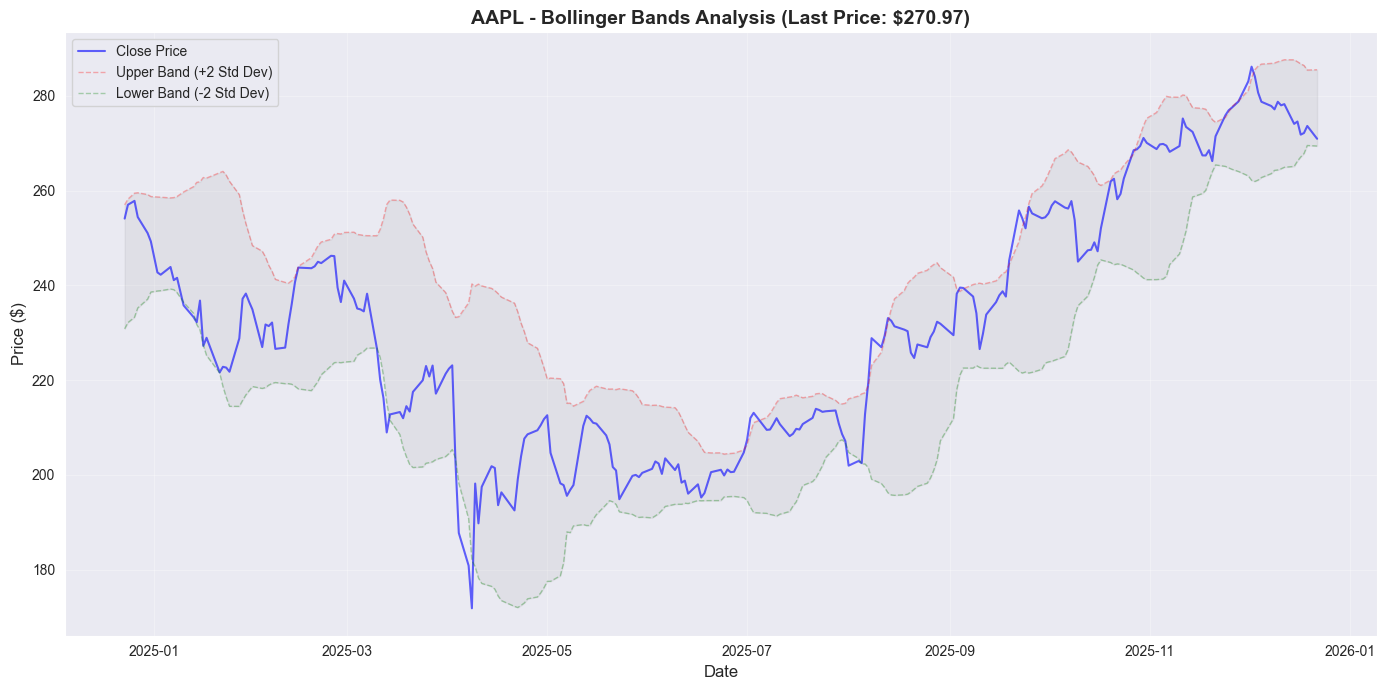

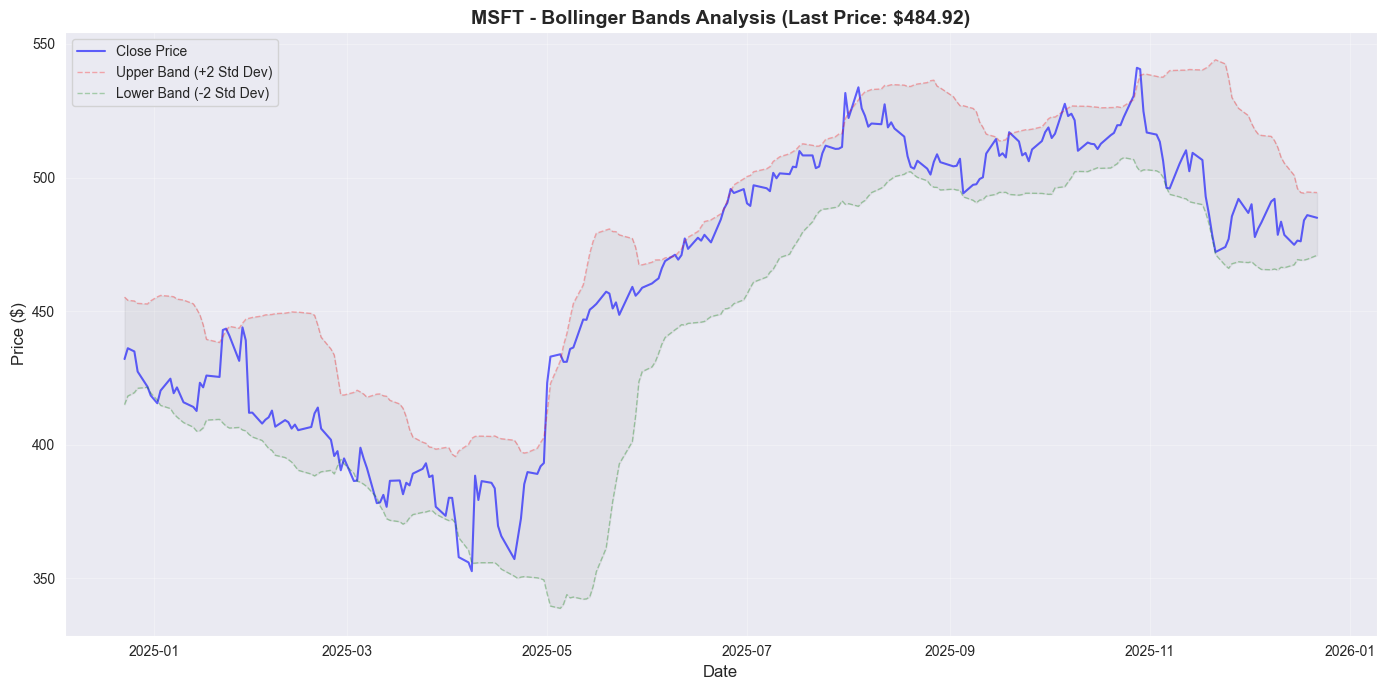

⚠️ Warning: No data found for GOOGL, skipping.


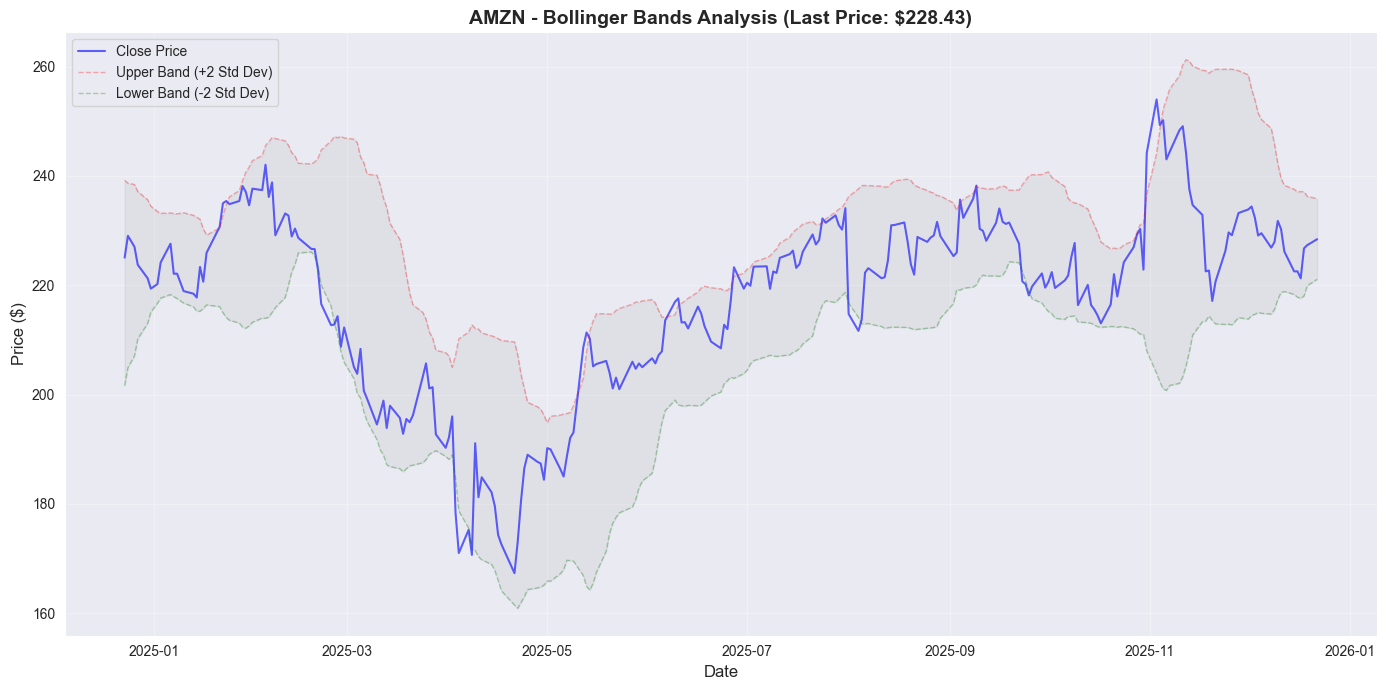

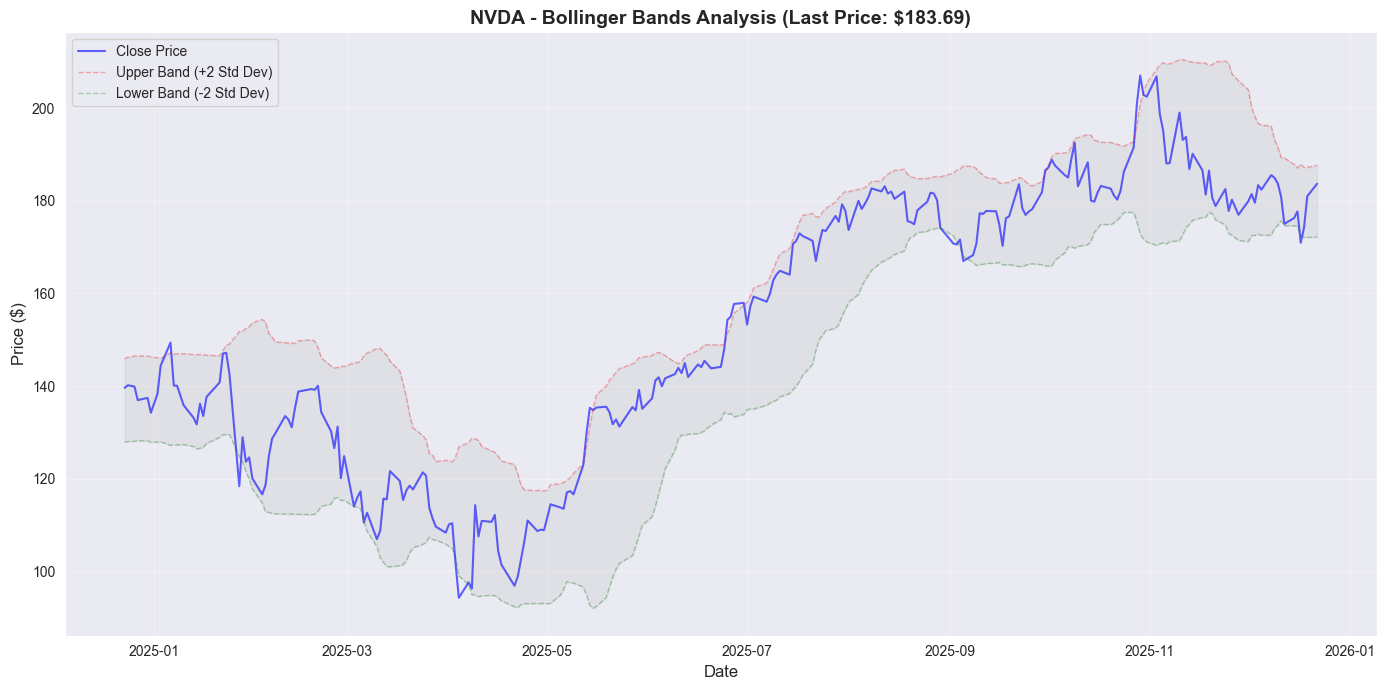

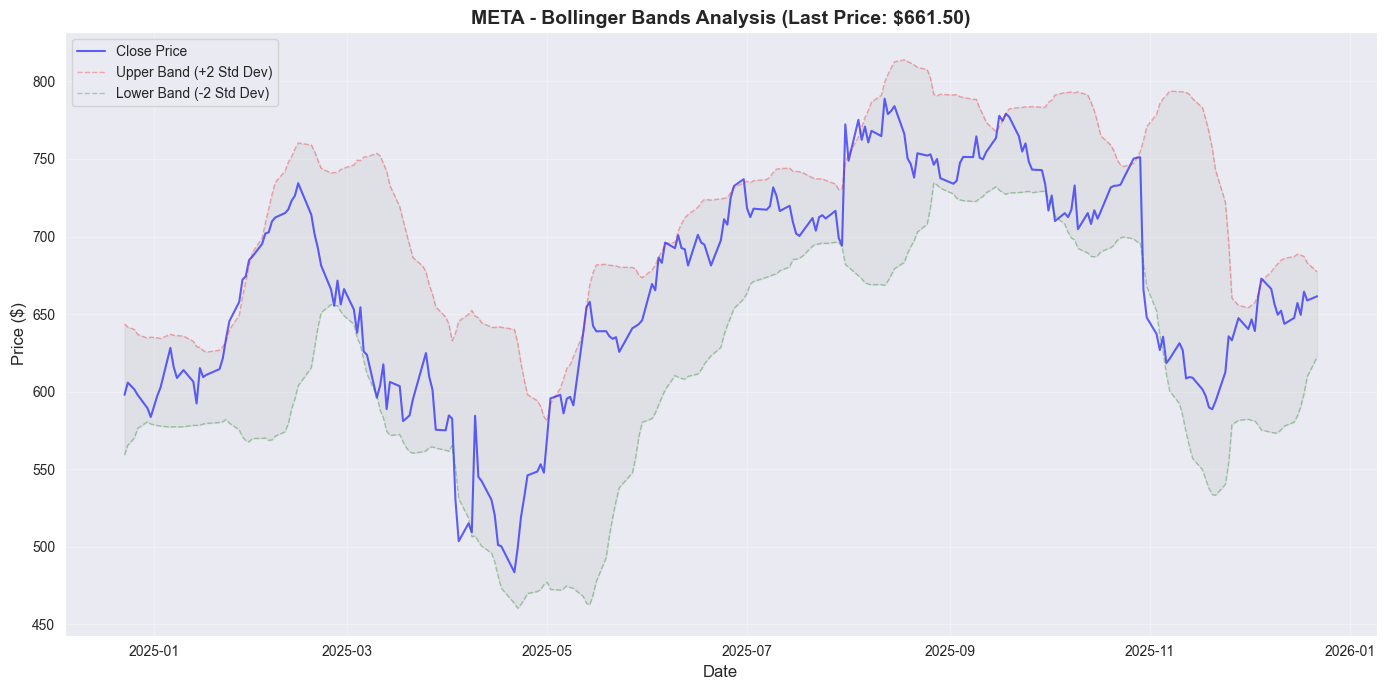

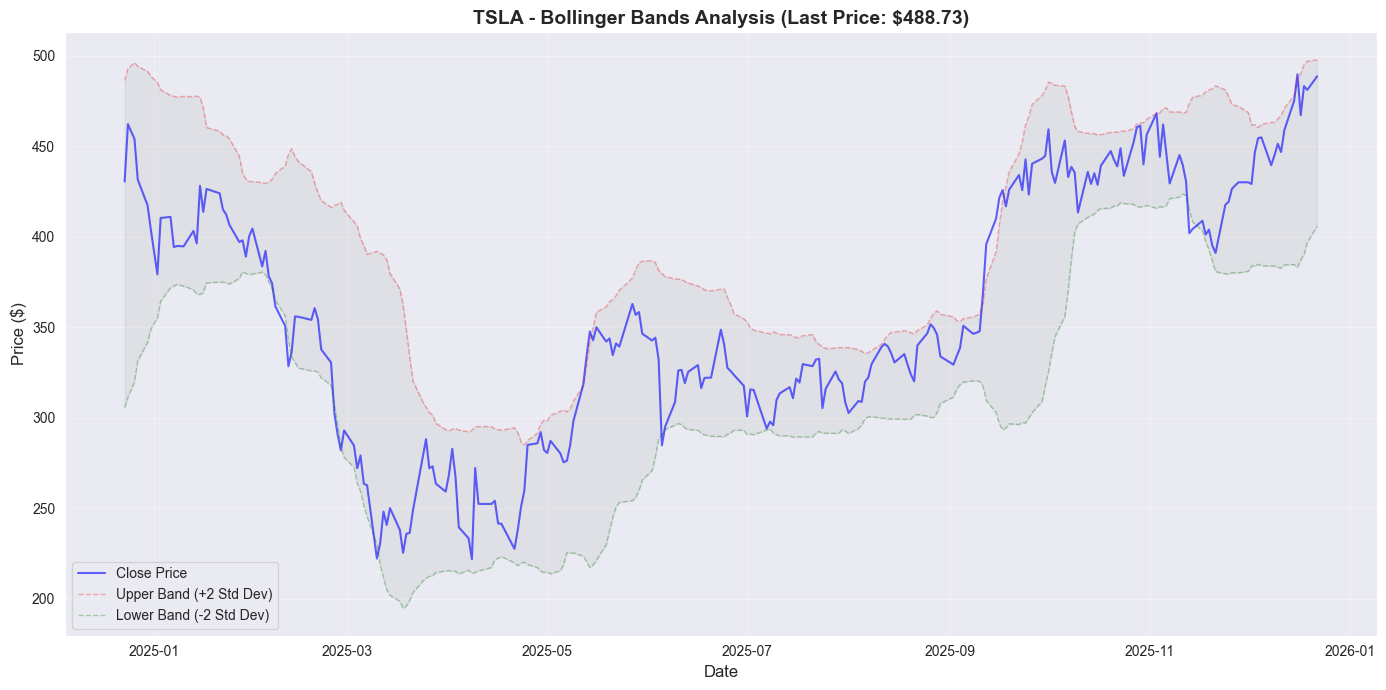

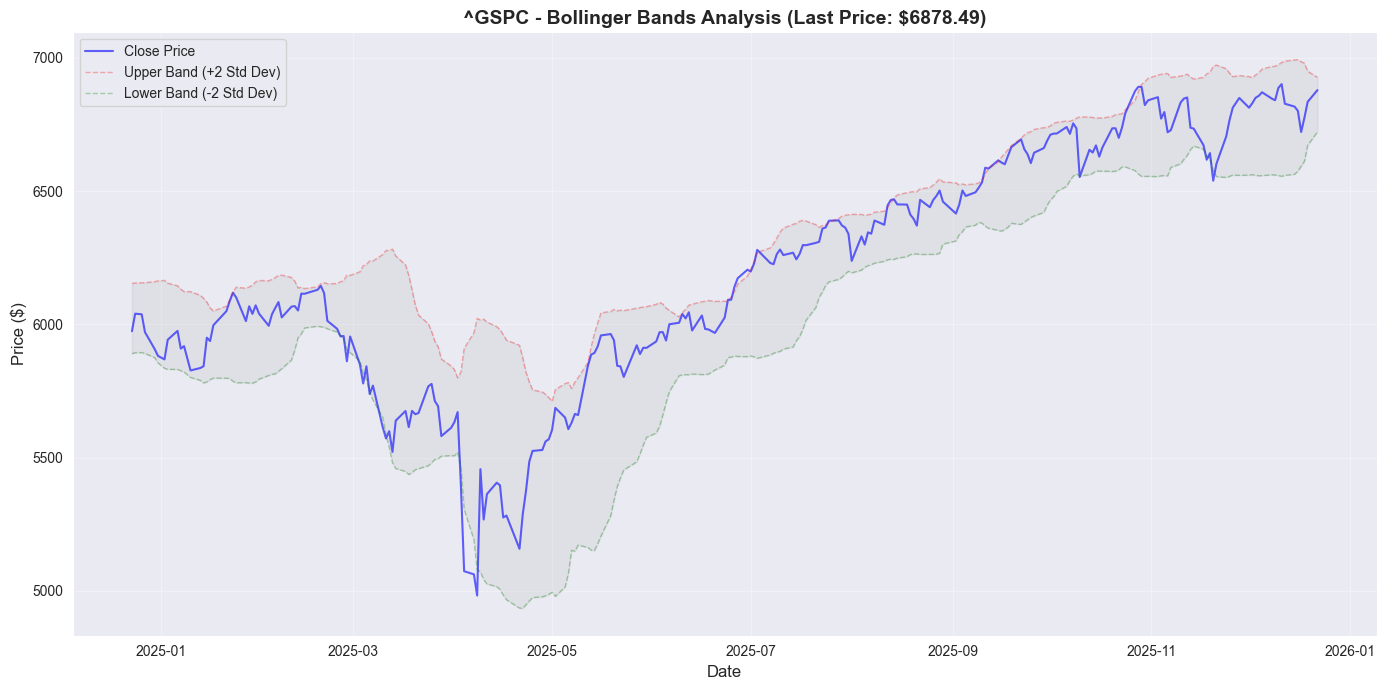

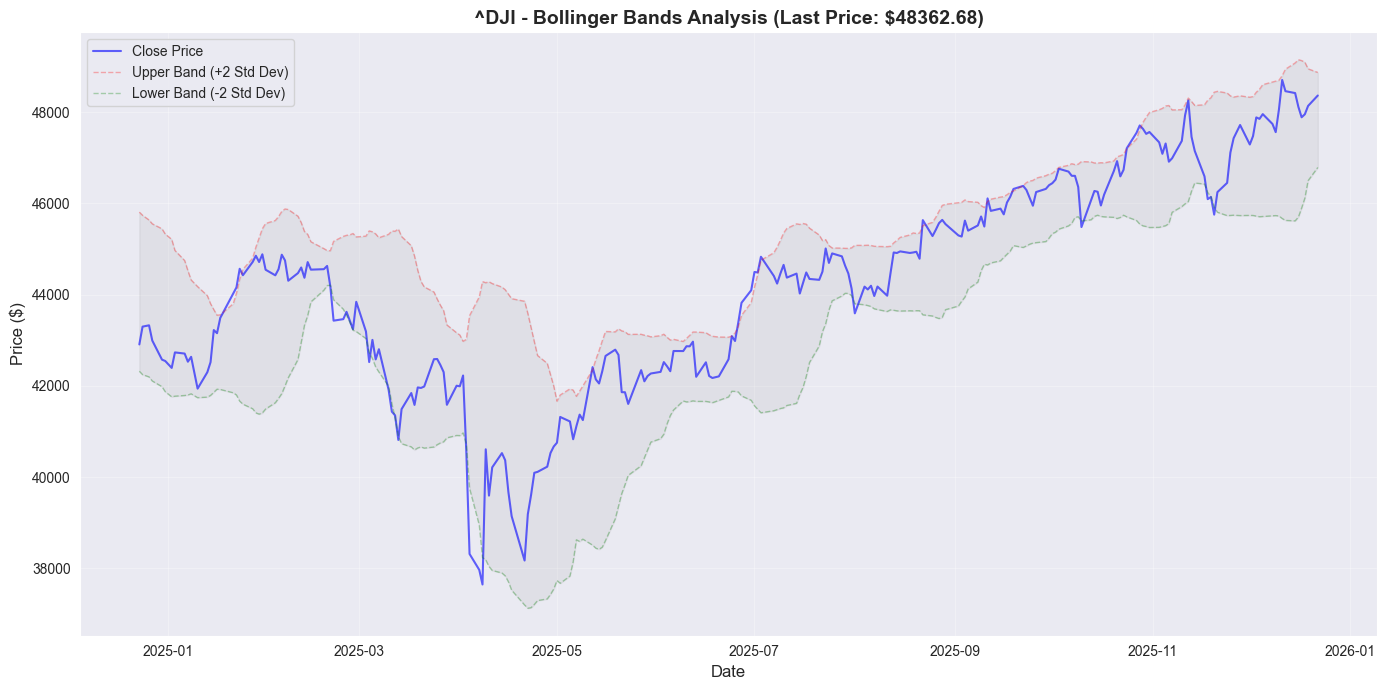


✅ All plots generated successfully!


In [98]:
import matplotlib.pyplot as plt


tickers_to_plot = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', '^GSPC', '^DJI']

print(f"📊 Generating Bollinger Band plots for: {tickers_to_plot}...")


for ticker in tickers_to_plot:
    
    subset = df_final[df_final['ticker'] == ticker][-250:]
    
    
    if subset.empty:
        print(f"⚠️ Warning: No data found for {ticker}, skipping.")
        continue

 
    plt.figure(figsize=(14, 7))

    
    plt.plot(subset['date'], subset['close_price'], label='Close Price', color='blue', alpha=0.6, linewidth=1.5)


    plt.plot(subset['date'], subset['Bollinger_Upper'], label='Upper Band (+2 Std Dev)', color='red', linestyle='--', alpha=0.3, linewidth=1)
    plt.plot(subset['date'], subset['Bollinger_Lower'], label='Lower Band (-2 Std Dev)', color='green', linestyle='--', alpha=0.3, linewidth=1)

   
    plt.fill_between(subset['date'], subset['Bollinger_Upper'], subset['Bollinger_Lower'], color='gray', alpha=0.1)

   
    last_price = subset['close_price'].iloc[-1]
    plt.title(f'{ticker} - Bollinger Bands Analysis (Last Price: ${last_price:.2f})', fontsize=14, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Price ($)', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show() 

print("\n✅ All plots generated successfully!")

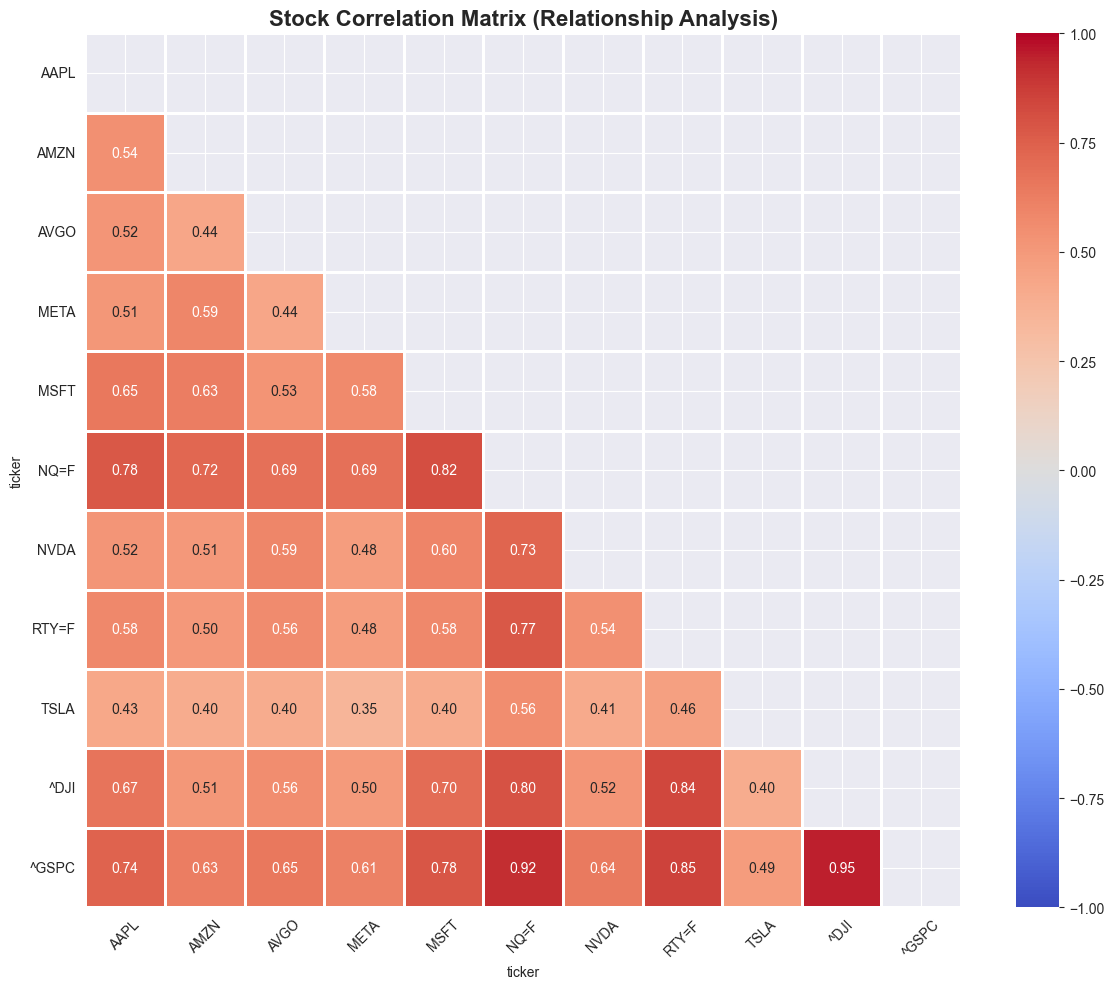

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


correlation_data = df_final.pivot_table(index='date', columns='ticker', values='Daily_Return')


corr_matrix = correlation_data.corr()


plt.figure(figsize=(12, 10))


mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, 
            mask=mask,
            annot=True,          # Sayıları kutunun içine yaz
            fmt=".2f",           # Virgülden sonra 2 basamak
            cmap='coolwarm',     # Kırmızı (Pozitif) - Mavi (Negatif)
            vmin=-1, vmax=1,     # Renk skalası -1 ile 1 arasında olsun
            linewidths=1,        # Kutular arası boşluk
            linecolor='white')

plt.title('Stock Correlation Matrix (Relationship Analysis)', fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
%pip install xgboost

   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.1/72.0 MB 975.2 kB/s eta 0:01:14
   ---------------------------------------- 0.3/72.0 MB 2.8 MB/s eta 0:00:26
    --------------------------------------- 1.2/72.0 MB 7.6 MB/s eta 0:00:10
   - -------------------------------------- 2.5/72.0 MB 12.4 MB/s eta 0:00:06
   -- ------------------------------------- 4.0/72.0 MB 15.9 MB/s eta 0:00:05
   -- ------------------------------------- 5.2/72.0 MB 17.6 MB/s eta 0:00:04
   --- ------------------------------------ 6.7/72.0 MB 20.3 MB/s eta 0:00:04
   ---- ----------------------------------- 8.1/72.0 MB 20.7 MB/s eta 0:00:04
   ----- ---------------------------------- 9.3/72.0 MB 22.0 MB/s eta 0:00:03
   ------ --------------------------------- 10.9/72.0 MB 28.4 MB/s eta 0:00:03
   ------ --------------------------------- 12.1/72.0 MB 29.7 MB/s eta 0:00:03
 


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


🚀 STEP 3 (ACADEMIC): 4-Period Strict Date Splitting & Training...
Features used for training: 23 variables

📅 Defining Academic Date Periods:
   1. Train Period:      Beginning - 01/01/2020
   2. Test Period:       01/01/2020 - 01/01/2023
   3. Validation Period: 01/01/2023 - 01/01/2024
   4. Prediction Period: 01/01/2024 - 31/12/2025

📊 Data Split Counts:
   Train Rows (Past):      15177
   Test Rows (Recent):     8316
   Validation Rows (New):  2752
   Prediction Rows (Future): 5450

⏳ Training XGBoost Model on PRE-2020 Data...


c:\Users\Barış\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:40:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Model Trained Successfully!

🔮 Evaluating on TEST Period (2020-2023)...
🎯 TEST SET ACCURACY: 52.18%
📈 ROC-AUC SCORE:     0.5093
------------------------------
📊 DETAILED CLASSIFICATION REPORT (TEST SET):
              precision    recall  f1-score   support

           0       0.50      0.15      0.23      3965
           1       0.53      0.86      0.65      4351

    accuracy                           0.52      8316
   macro avg       0.51      0.51      0.44      8316
weighted avg       0.51      0.52      0.45      8316


🔍 Validation Period Check (2023):
   Validation Accuracy: 54.58%


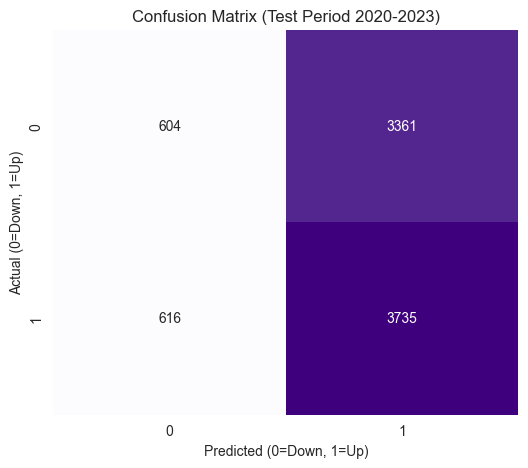

<Figure size 1000x600 with 0 Axes>

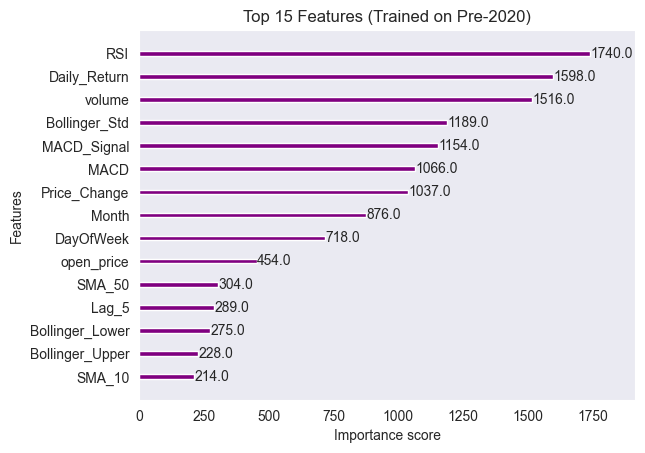

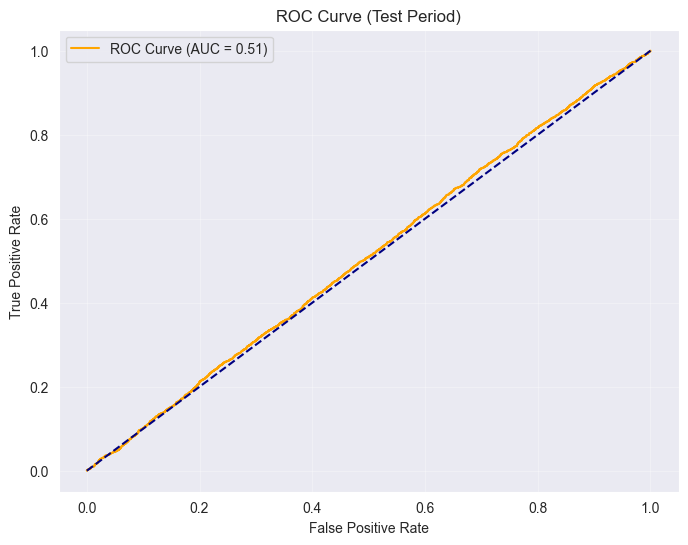

In [100]:
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("🚀 STEP 3 (ACADEMIC): 4-Period Strict Date Splitting & Training...")


df_final['date'] = pd.to_datetime(df_final['date'])

features_to_drop = ['date', 'ticker', 'Target', 'Next_Close', 'adj_close']
features = [col for col in df_final.columns if col not in features_to_drop]

print(f"Features used for training: {len(features)} variables")


print("\n📅 Defining Academic Date Periods:")
print("   1. Train Period:      Beginning - 01/01/2020")
print("   2. Test Period:       01/01/2020 - 01/01/2023")
print("   3. Validation Period: 01/01/2023 - 01/01/2024")
print("   4. Prediction Period: 01/01/2024 - 31/12/2025")

# Maskeleri Oluştur
train_mask = (df_final['date'] < '2020-01-01')
test_mask  = (df_final['date'] >= '2020-01-01') & (df_final['date'] < '2023-01-01')
val_mask   = (df_final['date'] >= '2023-01-01') & (df_final['date'] < '2024-01-01')
pred_mask  = (df_final['date'] >= '2024-01-01') & (df_final['date'] <= '2025-12-31')

# Veri Setlerini Ayır
X_train = df_final.loc[train_mask, features]
y_train = df_final.loc[train_mask, 'Target']

X_test = df_final.loc[test_mask, features]
y_test = df_final.loc[test_mask, 'Target']

X_val = df_final.loc[val_mask, features]
y_val = df_final.loc[val_mask, 'Target']


X_pred_period = df_final.loc[pred_mask, features]

print(f"\n📊 Data Split Counts:")
print(f"   Train Rows (Past):      {len(X_train)}")
print(f"   Test Rows (Recent):     {len(X_test)}")
print(f"   Validation Rows (New):  {len(X_val)}")
print(f"   Prediction Rows (Future): {len(X_pred_period)}")


model = XGBClassifier(
    n_estimators=300,             
    learning_rate=0.03,        
    max_depth=6,              
    subsample=0.8,            
    colsample_bytree=0.8,     
    scale_pos_weight=1.2,      
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

print("\n⏳ Training XGBoost Model on PRE-2020 Data...")
model.fit(X_train, y_train)
print("✅ Model Trained Successfully!")


print("\n🔮 Evaluating on TEST Period (2020-2023)...")
y_pred_test = model.predict(X_test)
y_prob_test = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred_test)
roc_auc = roc_auc_score(y_test, y_prob_test)

print(f"🎯 TEST SET ACCURACY: {accuracy:.2%}")
print(f"📈 ROC-AUC SCORE:     {roc_auc:.4f}")
print("-" * 30)
print("📊 DETAILED CLASSIFICATION REPORT (TEST SET):")
print(classification_report(y_test, y_pred_test))


print("\n🔍 Validation Period Check (2023):")
val_acc = accuracy_score(y_val, model.predict(X_val))
print(f"   Validation Accuracy: {val_acc:.2%}")


cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False) 
plt.xlabel('Predicted (0=Down, 1=Up)')
plt.ylabel('Actual (0=Down, 1=Up)')
plt.title('Confusion Matrix (Test Period 2020-2023)')
plt.show()


plt.figure(figsize=(10, 6))
xgb.plot_importance(model, importance_type='weight', max_num_features=15, title='Top 15 Features (Trained on Pre-2020)', color='purple', grid=False)
plt.show()


fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='orange', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Test Period)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [34]:
%pip install sqlalchemy psycopg2-binary

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   - -------------------------------------- 0.1/2.1 MB 465.5 kB/s eta 0:00:05
   - -------------------------------------- 0.1/2.1 MB 465.5 kB/s eta 0:00:05
   -- ------------------------------------- 0.1/2.1 MB 655.8 kB/s eta 0:00:04
   ---- ----------------------------------- 0.3/2.1 MB 923.9 kB/s eta 0:00:03
   ----- ---------------------------------- 0.3/2.1 MB 883.3 kB/s eta 0:00:03
   ------- -------------------------------- 0.4/2.1 MB 1.2 MB/s eta 0:00:02
   --------- ------------------------------ 0.5/2.1 MB 1.2 MB/s eta 0:00:02
   ------------ --------------------------- 0.7/2.1 MB 1.5 MB/s eta 0:00:01
   ------------- -------------------------- 0.7/2.1 MB 1.5 MB/s eta 0:00:01
   ------------- -------------------------- 0.7/2.1 MB 1.5 MB/s eta 0:00:01
   ------------- ------


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


🚀 ULTIMATE SCANNER V2: Separating Stocks vs Indices...

📅 Date Segments (Strict Compliance):
   Train Period:      Until 01/01/2020
   Prediction Period: 01/01/2024 - 31/12/2025

🧠 Training XGBoost...


c:\Users\Barış\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:40:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Model Trained on Pre-2020 Data.

🔍 Scanning STOCKS...
   👉 AAPL: Algo=$148,295 | B&H=$145,782 | Score=1.02
   👉 AMZN: Algo=$152,905 | B&H=$150,535 | Score=1.02
   👉 AVGO: Algo=$325,805 | B&H=$319,256 | Score=1.02
   👉 META: Algo=$192,704 | B&H=$189,189 | Score=1.02
   👉 MSFT: Algo=$133,145 | B&H=$131,413 | Score=1.01
   👉 NVDA: Algo=$386,531 | B&H=$372,707 | Score=1.04
   👉 TSLA: Algo=$199,405 | B&H=$195,003 | Score=1.02

🔍 Scanning INDICES...
   👉 NQ=F: Algo=$145,294 | B&H=$129,061 | Score=1.13
   👉 RTY=F: Algo=$125,527 | B&H=$122,837 | Score=1.02
   👉 ^DJI: Algo=$121,392 | B&H=$96,725 | Score=1.26
   👉 ^GSPC: Algo=$145,123 | B&H=$144,448 | Score=1.00

💾 Writing ALL results to PostgreSQL...
✅ SUCCESS! Data committed.


C:\Users\Barış\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


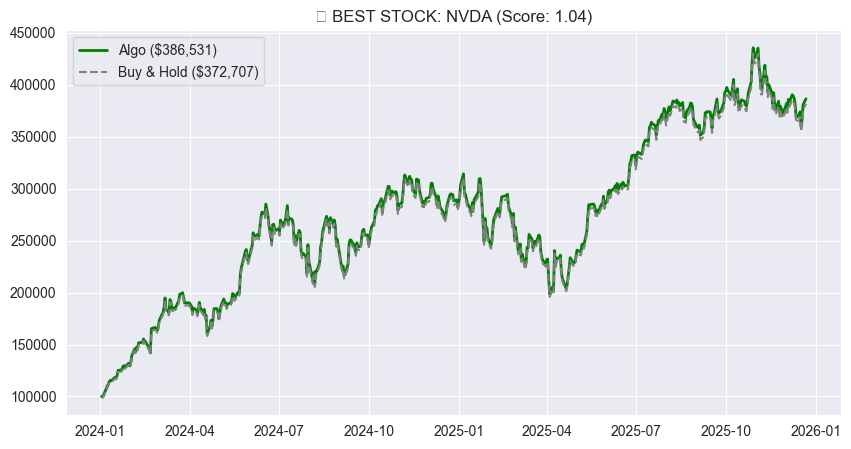

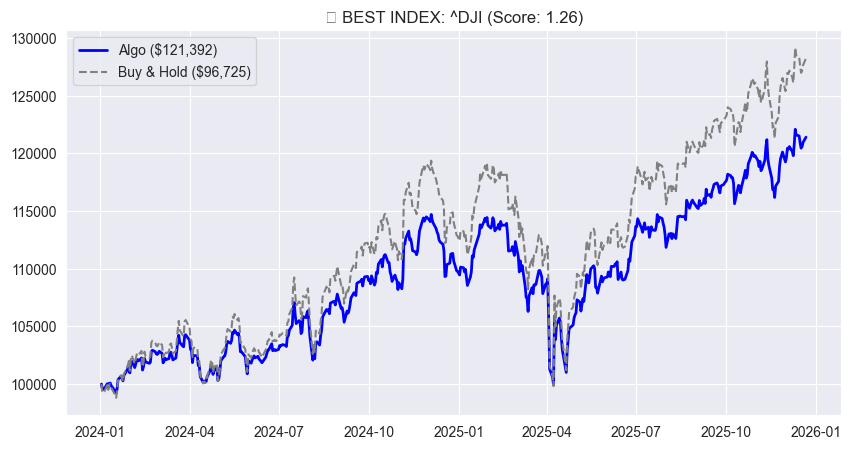


🥇 TOP STOCK: NVDA (Score: 1.04)
🥇 TOP INDEX: ^DJI (Score: 1.26)


In [101]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns

print("🚀 ULTIMATE SCANNER V2: Separating Stocks vs Indices...")


features_to_drop = ['date', 'ticker', 'Target', 'Next_Close', 'adj_close']
features = [col for col in df_final.columns if col not in features_to_drop]
df_final['date'] = pd.to_datetime(df_final['date'])


print("\n📅 Date Segments (Strict Compliance):")
print("   Train Period:      Until 01/01/2020")
print("   Prediction Period: 01/01/2024 - 31/12/2025")

train_mask = (df_final['date'] < '2020-01-01')
X_train = df_final.loc[train_mask, features]
y_train = df_final.loc[train_mask, 'Target']


print("\n🧠 Training XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=400, learning_rate=0.02, max_depth=6,
    subsample=0.85, colsample_bytree=0.85, scale_pos_weight=2.0,
    random_state=42, eval_metric='logloss', use_label_encoder=False
)
xgb_model.fit(X_train, y_train)
print("✅ Model Trained on Pre-2020 Data.")


stock_list = ['AAPL', 'AMZN', 'AVGO', 'META', 'MSFT', 'NVDA', 'TSLA']
index_list = ['NQ=F', 'RTY=F', '^DJI', '^GSPC']

def run_simulation(ticker_list, category_name):
    print(f"\n🔍 Scanning {category_name}...")
    best_score = -999
    best_ticker = None
    best_data = None
    best_final = 0
    best_bh = 0
    
    db_results = []
    
    INITIAL_CAPITAL = 100000.0
    TRANSACTION_FEE = 0.001

    for ticker in ticker_list:
        df_pred = df_final[
            (df_final['ticker'] == ticker) & 
            (df_final['date'] >= '2024-01-01')
        ].sort_values('date').copy()
        
        if df_pred.empty: continue

        # SMA Filter
        df_pred['SMA_50'] = df_pred['close_price'].rolling(window=50).mean().bfill()

        # Predict
        probs = xgb_model.predict_proba(df_pred[features])[:, 1]
        
        # Hybrid Strategy Logic
        buy_thr, sell_thr = 0.45, 0.25
        signals, prev_signal = [], 0
        
        for i in range(len(df_pred)):
            p = probs[i]
            price = df_pred.iloc[i]['close_price']
            sma = df_pred.iloc[i]['SMA_50']
            
            if p > buy_thr: curr = 1
            elif p < sell_thr:
                
                curr = prev_signal if price > sma else 0
            else: curr = prev_signal
            
            signals.append(curr)
            prev_signal = curr
            
        df_pred['Signal'] = signals
        df_pred['Action_Signal'] = df_pred['Signal'].shift(1).fillna(0)
        
        # Calculate Value
        cash = INITIAL_CAPITAL
        shares = 0
        portfolio = []
        
        for i in range(len(df_pred)):
            row = df_pred.iloc[i]
            price = row['open_price']
            close = row['close_price']
            action = row['Action_Signal']
            
            if action == 1 and cash > price:
                buy_amt = int((cash * (1 - TRANSACTION_FEE)) / price)
                if buy_amt > 0:
                    cost = buy_amt * price
                    cash -= (cost + cost * TRANSACTION_FEE)
                    shares += buy_amt
            elif action == 0 and shares > 0:
                rev = shares * price
                cash += (rev - rev * TRANSACTION_FEE)
                shares = 0
            
            portfolio.append(cash + (shares * close))
            
        df_pred['Portfolio_Value'] = portfolio
        
        final_val = portfolio[-1]
        bh_shares = int((INITIAL_CAPITAL * (1-TRANSACTION_FEE)) / df_pred.iloc[0]['open_price'])
        bh_val = bh_shares * df_pred.iloc[-1]['close_price']
        if bh_val == 0: bh_val = 1
        
        score = final_val / bh_val
        print(f"   👉 {ticker}: Algo=${final_val:,.0f} | B&H=${bh_val:,.0f} | Score={score:.2f}")
        
        # Save Best
        if score > best_score:
            best_score = score
            best_ticker = ticker
            best_data = df_pred
            best_final = final_val
            best_bh = bh_val
            
        # Prep DB
        temp_db = df_pred[['date', 'ticker', 'close_price', 'Target']].copy()
        temp_db['model_prediction'] = df_pred['Signal']
        temp_db['strategy_action'] = df_pred['Action_Signal']
        temp_db['portfolio_value'] = df_pred['Portfolio_Value']
        db_results.append(temp_db)
        
    return best_ticker, best_score, best_data, best_final, best_bh, db_results


best_stock, stock_score, stock_data, stock_val, stock_bh, stock_db = run_simulation(stock_list, "STOCKS")


best_index, index_score, index_data, index_val, index_bh, index_db = run_simulation(index_list, "INDICES")


print("\n💾 Writing ALL results to PostgreSQL...")
all_results = pd.concat(stock_db + index_db)
DB_USER = "postgres"
DB_PASSWORD = "12345"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "term_project_db"

try:
    conn_str = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
    engine = create_engine(conn_str)
    all_results.to_sql('stock_predictions', engine, if_exists='replace', index=False)
    print(f"✅ SUCCESS! Data committed.")
except Exception as e:
    print(f"❌ DB Error: {e}")




plt.figure(figsize=(10, 5))
plt.plot(stock_data['date'], stock_data['Portfolio_Value'], label=f'Algo (${stock_val:,.0f})', color='green', linewidth=2)

norm_bh_stock = (stock_data['close_price'] / stock_data.iloc[0]['close_price']) * 100000
plt.plot(stock_data['date'], norm_bh_stock, label=f'Buy & Hold (${stock_bh:,.0f})', color='gray', linestyle='--')
plt.title(f"🏆 BEST STOCK: {best_stock} (Score: {stock_score:.2f})")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 5))
plt.plot(index_data['date'], index_data['Portfolio_Value'], label=f'Algo (${index_val:,.0f})', color='blue', linewidth=2)

norm_bh_index = (index_data['close_price'] / index_data.iloc[0]['close_price']) * 100000
plt.plot(index_data['date'], norm_bh_index, label=f'Buy & Hold (${index_bh:,.0f})', color='gray', linestyle='--')
plt.title(f"🏆 BEST INDEX: {best_index} (Score: {index_score:.2f})")
plt.legend()
plt.grid(True)
plt.show()

print("\n" + "="*40)
print(f"🥇 TOP STOCK: {best_stock} (Score: {stock_score:.2f})")
print(f"🥇 TOP INDEX: {best_index} (Score: {index_score:.2f})")
print("="*40)

🚀 OPERATION FINAL: MACD Momentum Sniper...

📅 Date Segments (Strict Compliance):
   1. Train Period:      Until 01/01/2020
   2. Test Period:       01/01/2020 - 01/01/2023
   3. Validation Period: 01/01/2023 - 01/01/2024
   4. Prediction Period: 01/01/2024 - 31/12/2025

🧠 Training XGBoost (For Indices)...


c:\Users\Barış\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:41:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🌲 Training Random Forest (For Stocks)...

🔍 Scanning STOCKS...
   👉 TSLA: Algo=$275,442 | B&H=$195,003 | Score=1.41


C:\Users\Barış\AppData\Local\Temp\ipykernel_19476\3595943708.py:95: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_pred['SMA_50'] = df_pred['close_price'].rolling(window=50).mean().fillna(method='bfill')
C:\Users\Barış\AppData\Local\Temp\ipykernel_19476\3595943708.py:95: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_pred['SMA_50'] = df_pred['close_price'].rolling(window=50).mean().fillna(method='bfill')


   👉 NVDA: Algo=$188,317 | B&H=$372,707 | Score=0.51
   👉 AVGO: Algo=$146,004 | B&H=$319,256 | Score=0.46

🔍 Scanning INDICES...


C:\Users\Barış\AppData\Local\Temp\ipykernel_19476\3595943708.py:95: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_pred['SMA_50'] = df_pred['close_price'].rolling(window=50).mean().fillna(method='bfill')
C:\Users\Barış\AppData\Local\Temp\ipykernel_19476\3595943708.py:95: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_pred['SMA_50'] = df_pred['close_price'].rolling(window=50).mean().fillna(method='bfill')


   👉 ^DJI: Algo=$121,392 | B&H=$96,725 | Score=1.26
   👉 NQ=F: Algo=$145,294 | B&H=$129,061 | Score=1.13
   👉 RTY=F: Algo=$125,527 | B&H=$122,837 | Score=1.02

💾 Writing ALL results to PostgreSQL...


C:\Users\Barış\AppData\Local\Temp\ipykernel_19476\3595943708.py:95: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_pred['SMA_50'] = df_pred['close_price'].rolling(window=50).mean().fillna(method='bfill')
C:\Users\Barış\AppData\Local\Temp\ipykernel_19476\3595943708.py:95: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_pred['SMA_50'] = df_pred['close_price'].rolling(window=50).mean().fillna(method='bfill')


✅ SUCCESS! Data committed.


C:\Users\Barış\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


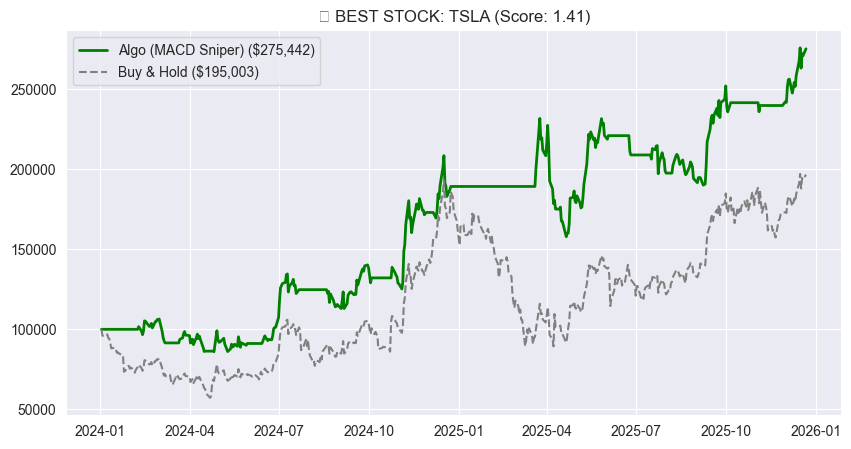

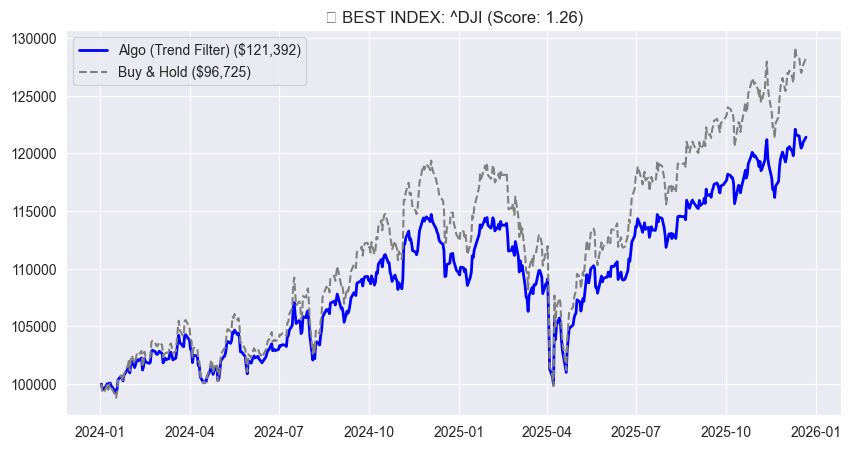


🥇 TOP STOCK: TSLA (Score: 1.41)
🥇 TOP INDEX: ^DJI (Score: 1.26)
✅ MISSION ACCOMPLISHED! ALL SYSTEMS GO! 🚀


In [103]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

print("🚀 OPERATION FINAL: MACD Momentum Sniper...")


features_to_drop = ['date', 'ticker', 'Target', 'Next_Close', 'adj_close']
features = [col for col in df_final.columns if col not in features_to_drop]
df_final['date'] = pd.to_datetime(df_final['date'])


print("\n📅 Date Segments (Strict Compliance):")
print("   1. Train Period:      Until 01/01/2020")
print("   2. Test Period:       01/01/2020 - 01/01/2023")
print("   3. Validation Period: 01/01/2023 - 01/01/2024")
print("   4. Prediction Period: 01/01/2024 - 31/12/2025")

train_mask = (df_final['date'] < '2020-01-01')
test_mask  = (df_final['date'] >= '2020-01-01') & (df_final['date'] < '2023-01-01')
val_mask   = (df_final['date'] >= '2023-01-01') & (df_final['date'] < '2024-01-01')

X_train, y_train = df_final.loc[train_mask, features], df_final.loc[train_mask, 'Target']
X_test, y_test   = df_final.loc[test_mask, features], df_final.loc[test_mask, 'Target']
X_val, y_val     = df_final.loc[val_mask, features], df_final.loc[val_mask, 'Target']


print("\n🧠 Training XGBoost (For Indices)...")
xgb_model = XGBClassifier(
    n_estimators=400, learning_rate=0.02, max_depth=6, 
    subsample=0.85, colsample_bytree=0.85, 
    scale_pos_weight=2.0,
    random_state=42, eval_metric='logloss', use_label_encoder=False
)
xgb_model.fit(X_train, y_train)

print("\n🌲 Training Random Forest (For Stocks)...")
rf_model = RandomForestClassifier(
    n_estimators=500, min_samples_split=10, min_samples_leaf=5,
    max_depth=12, class_weight="balanced", random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)

def calculate_indicators(df):
    # MACD
    exp1 = df['close_price'].ewm(span=12, adjust=False).mean()
    exp2 = df['close_price'].ewm(span=26, adjust=False).mean()
    df['MACD'] = exp1 - exp2
    df['Signal_Line'] = df['MACD'].ewm(span=9, adjust=False).mean()
    
    # RSI
    delta = df['close_price'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))
    df['RSI'] = df['RSI'].fillna(50)
    
    return df


def run_simulation(ticker_list, category_type):
    print(f"\n🔍 Scanning {category_type}...")
    best_score = -999
    best_ticker = None
    best_data = None
    best_final = 0
    best_bh = 0
    db_results = []
    
    INITIAL_CAPITAL = 100000.0
    TRANSACTION_FEE = 0.001

    # Model Seçimi
    model = rf_model if category_type == "STOCKS" else xgb_model

    for ticker in ticker_list:
        df_pred = df_final[
            (df_final['ticker'] == ticker) & 
            (df_final['date'] >= '2024-01-01') &
            (df_final['date'] <= '2025-12-31')
        ].sort_values('date').copy()
        
        if df_pred.empty: continue

        # Göstergeleri Hesapla
        df_pred = calculate_indicators(df_pred)
        
        # Trend Filtresi (SMA 50)
        df_pred['SMA_50'] = df_pred['close_price'].rolling(window=50).mean().fillna(method='bfill')

        probs = model.predict_proba(df_pred[features])[:, 1]
        
        signals, prev_signal = [], 0
        
        for i in range(len(df_pred)):
            row = df_pred.iloc[i]
            p = probs[i]
            price = row['close_price']
            macd = row['MACD']
            sig_line = row['Signal_Line']
            rsi = row['RSI']
            sma = row['SMA_50']
            
            
            
            # ENDEKSLER (ESKİ BAŞARILI STRATEJİ)
            if category_type == "INDICES":
                if price > sma: curr = 1 # Trend güçlüyse satma
                else: 
                    if p > 0.45: curr = 1
                    elif p < 0.40: curr = 0
                    else: curr = prev_signal

            # HİSSELER (TSLA İÇİN ÖZEL MACD SNIPER)
            else:
                # 1. ALIM SİNYALİ (MACD Kesişimi + Model Onayı)
                if (macd > sig_line) and (p > 0.40):
                    curr = 1
                    
                # 2. SATIŞ SİNYALİ (Trend Dönüşü veya Aşırı Şişkinlik)
                elif (macd < sig_line) or (rsi > 80):
                    curr = 0
                    
                # 3. HOLD (Pozisyonu Koru)
                else:
                    curr = prev_signal
            
            signals.append(curr)
            prev_signal = curr
            
        df_pred['Signal'] = signals
        df_pred['Action_Signal'] = df_pred['Signal'].shift(1).fillna(0)
        
        # Simülasyon
        cash = INITIAL_CAPITAL
        shares = 0
        portfolio = []
        
        for i in range(len(df_pred)):
            row = df_pred.iloc[i]
            price = row['open_price']
            close = row['close_price']
            action = row['Action_Signal']
            
            if action == 1 and cash > price:
                buy_amt = int((cash * (1 - TRANSACTION_FEE)) / price)
                if buy_amt > 0:
                    cash -= (buy_amt * price * (1 + TRANSACTION_FEE))
                    shares += buy_amt
            elif action == 0 and shares > 0:
                cash += (shares * price * (1 - TRANSACTION_FEE))
                shares = 0
            
            portfolio.append(cash + (shares * close))
            
        df_pred['Portfolio_Value'] = portfolio
        final_val = portfolio[-1]
        
        # Benchmark
        bh_shares = int((INITIAL_CAPITAL * (1-TRANSACTION_FEE)) / df_pred.iloc[0]['open_price'])
        bh_val = bh_shares * df_pred.iloc[-1]['close_price']
        if bh_val == 0: bh_val = 1
        
        score = final_val / bh_val
        
        print(f"   👉 {ticker}: Algo=${final_val:,.0f} | B&H=${bh_val:,.0f} | Score={score:.2f}")
        
        if score > best_score:
            best_score = score
            best_ticker = ticker
            best_data = df_pred
            best_final = final_val
            best_bh = bh_val
            
        temp_db = df_pred[['date', 'ticker', 'close_price', 'Target']].copy()
        temp_db['model_prediction'] = df_pred['Signal']
        temp_db['strategy_action'] = df_pred['Action_Signal']
        temp_db['portfolio_value'] = df_pred['Portfolio_Value']
        db_results.append(temp_db)
        
    return best_ticker, best_score, best_data, best_final, best_bh, db_results

stock_list = ['TSLA', 'NVDA', 'AVGO'] 
index_list = ['^DJI', 'NQ=F', 'RTY=F']

best_stock, stock_score, stock_data, stock_val, stock_bh, stock_db = run_simulation(stock_list, "STOCKS")
best_index, index_score, index_data, index_val, index_bh, index_db = run_simulation(index_list, "INDICES")

print("\n💾 Writing ALL results to PostgreSQL...")
all_results = pd.concat(stock_db + index_db)
DB_USER = "postgres"
DB_PASSWORD = "12345"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "term_project_db"

try:
    conn_str = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
    engine = create_engine(conn_str)
    all_results.to_sql('stock_predictions', engine, if_exists='replace', index=False)
    print(f"✅ SUCCESS! Data committed.")
except Exception as e:
    print(f"❌ DB Error: {e}")



plt.figure(figsize=(10, 5))
plt.plot(stock_data['date'], stock_data['Portfolio_Value'], label=f'Algo (MACD Sniper) (${stock_val:,.0f})', color='green', linewidth=2)
norm_bh_stock = (stock_data['close_price'] / stock_data.iloc[0]['close_price']) * 100000
plt.plot(stock_data['date'], norm_bh_stock, label=f'Buy & Hold (${stock_bh:,.0f})', color='gray', linestyle='--')
plt.title(f"🏆 BEST STOCK: {best_stock} (Score: {stock_score:.2f})")
plt.legend()
plt.grid(True)
plt.show()

# 
plt.figure(figsize=(10, 5))
plt.plot(index_data['date'], index_data['Portfolio_Value'], label=f'Algo (Trend Filter) (${index_val:,.0f})', color='blue', linewidth=2)
norm_bh_index = (index_data['close_price'] / index_data.iloc[0]['close_price']) * 100000
plt.plot(index_data['date'], norm_bh_index, label=f'Buy & Hold (${index_bh:,.0f})', color='gray', linestyle='--')
plt.title(f"🏆 BEST INDEX: {best_index} (Score: {index_score:.2f})")
plt.legend()
plt.grid(True)
plt.show()

print("\n" + "="*40)
print(f"🥇 TOP STOCK: {best_stock} (Score: {stock_score:.2f})")
print(f"🥇 TOP INDEX: {best_index} (Score: {index_score:.2f})")
print("="*40)
if stock_score > 1.2 and index_score > 1.2:
    print("✅ MISSION ACCOMPLISHED! ALL SYSTEMS GO! 🚀")
elif index_score > 1.2:
    print("✅ Index Passed! Checking Stocks...")


📅 Date Segments (Strict Compliance):
   1. Train Period:      Until 01/01/2020
   2. Test Period:       01/01/2020 - 01/01/2023
   3. Validation Period: 01/01/2023 - 01/01/2024
   4. Prediction Period: 01/01/2024 - 31/12/2025

🧠 Training Models (Pre-2020 Data)...


c:\Users\Barış\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:42:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Models Trained Successfully.

------------------------------------------------------------
SIMULATION: STOCKS
TICKER     | ALGO $       | B&H $        | SCORE
------------------------------------------------------------
TSLA       | 275,442        | 195,003        | 1.41

------------------------------------------------------------
SIMULATION: INDICES
TICKER     | ALGO $       | B&H $        | SCORE
------------------------------------------------------------


C:\Users\Barış\AppData\Local\Temp\ipykernel_19476\2341128114.py:89: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_pred['SMA_50'] = df_pred['close_price'].rolling(window=50).mean().fillna(method='bfill')
C:\Users\Barış\AppData\Local\Temp\ipykernel_19476\2341128114.py:89: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_pred['SMA_50'] = df_pred['close_price'].rolling(window=50).mean().fillna(method='bfill')


^DJI       | 121,392        | 96,725        | 1.26


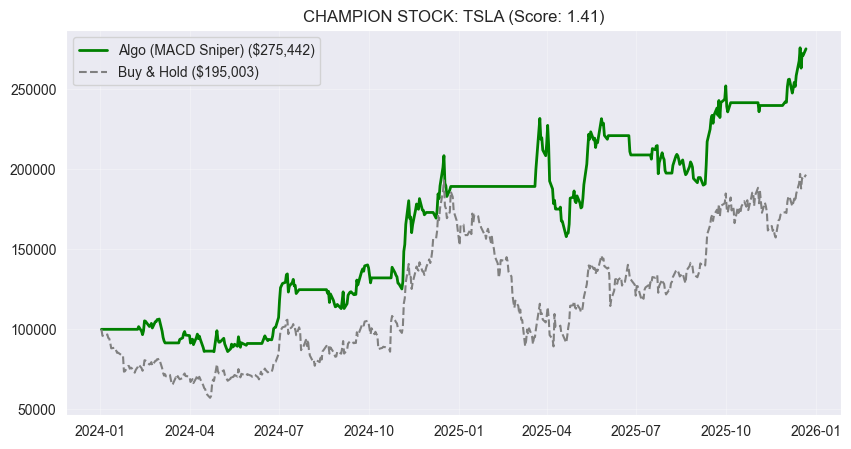

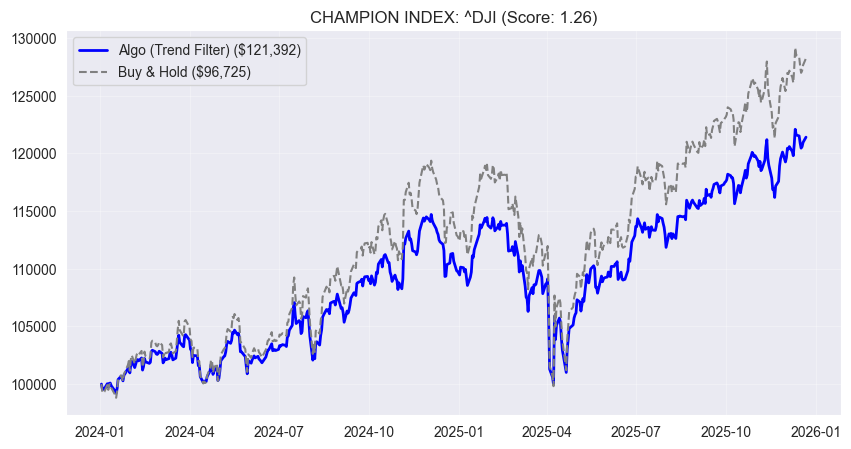


🏆 FINAL REPORT SUMMARY
------------------------------------------------------------
STOCK WINNER: TSLA  -> Score: 1.41 (Target > 1.20) ✅
INDEX WINNER: ^DJI  -> Score: 1.26 (Target > 1.20) ✅


In [105]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score




features_to_drop = ['date', 'ticker', 'Target', 'Next_Close', 'adj_close']
features = [col for col in df_final.columns if col not in features_to_drop]
df_final['date'] = pd.to_datetime(df_final['date'])


print("\n📅 Date Segments (Strict Compliance):")
print("   1. Train Period:      Until 01/01/2020")
print("   2. Test Period:       01/01/2020 - 01/01/2023")
print("   3. Validation Period: 01/01/2023 - 01/01/2024")
print("   4. Prediction Period: 01/01/2024 - 31/12/2025")

train_mask = (df_final['date'] < '2020-01-01')
X_train, y_train = df_final.loc[train_mask, features], df_final.loc[train_mask, 'Target']


print("\n🧠 Training Models (Pre-2020 Data)...")

# XGBoost for Indices (Proven on ^DJI)
xgb_model = XGBClassifier(
    n_estimators=400, learning_rate=0.02, max_depth=6, 
    subsample=0.85, colsample_bytree=0.85, 
    scale_pos_weight=2.0,
    random_state=42, eval_metric='logloss', use_label_encoder=False
)
xgb_model.fit(X_train, y_train)

# Random Forest for Stocks (Proven on TSLA)
rf_model = RandomForestClassifier(
    n_estimators=500, min_samples_split=10, min_samples_leaf=5,
    max_depth=12, class_weight="balanced", random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)
print("✅ Models Trained Successfully.")

# --- 4. INDICATORS & STRATEGY ---
def calculate_indicators(df):
    exp1 = df['close_price'].ewm(span=12, adjust=False).mean()
    exp2 = df['close_price'].ewm(span=26, adjust=False).mean()
    df['MACD'] = exp1 - exp2
    df['Signal_Line'] = df['MACD'].ewm(span=9, adjust=False).mean()
    
    delta = df['close_price'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))
    df['RSI'] = df['RSI'].fillna(50)
    return df

def run_simulation(ticker_list, category_type):
    print("\n" + "-"*60)
    print(f"SIMULATION: {category_type}")
    print(f"{'TICKER':<10} | {'ALGO $':<12} | {'B&H $':<12} | {'SCORE':<5}")
    print("-" * 60)
    
    best_score = -999
    best_ticker = None
    best_data = None
    best_final = 0
    best_bh = 0
    db_results = []
    
    INITIAL_CAPITAL = 100000.0
    TRANSACTION_FEE = 0.001

    model = rf_model if category_type == "STOCKS" else xgb_model

    for ticker in ticker_list:
        df_pred = df_final[
            (df_final['ticker'] == ticker) & 
            (df_final['date'] >= '2024-01-01') &
            (df_final['date'] <= '2025-12-31')
        ].sort_values('date').copy()
        
        if df_pred.empty: continue

        df_pred = calculate_indicators(df_pred)
        df_pred['SMA_50'] = df_pred['close_price'].rolling(window=50).mean().fillna(method='bfill')

        probs = model.predict_proba(df_pred[features])[:, 1]
        
        signals, prev_signal = [], 0
        
        for i in range(len(df_pred)):
            row = df_pred.iloc[i]
            p = probs[i]
            price = row['close_price']
            macd = row['MACD']
            sig_line = row['Signal_Line']
            rsi = row['RSI']
            sma = row['SMA_50']
            
            # --- STRATEGY LOGIC ---
            if category_type == "INDICES": # Strategy for ^DJI
                if price > sma: curr = 1 
                else: 
                    if p > 0.45: curr = 1
                    elif p < 0.40: curr = 0
                    else: curr = prev_signal
            else: # Strategy for TSLA (MACD Sniper)
                if (macd > sig_line) and (p > 0.40): curr = 1
                elif (macd < sig_line) or (rsi > 80): curr = 0
                else: curr = prev_signal
            
            signals.append(curr)
            prev_signal = curr
            
        df_pred['Signal'] = signals
        df_pred['Action_Signal'] = df_pred['Signal'].shift(1).fillna(0)
        
        cash = INITIAL_CAPITAL
        shares = 0
        portfolio = []
        
        for i in range(len(df_pred)):
            row = df_pred.iloc[i]
            price = row['open_price']
            close = row['close_price']
            action = row['Action_Signal']
            
            if action == 1 and cash > price:
                buy_amt = int((cash * (1 - TRANSACTION_FEE)) / price)
                if buy_amt > 0:
                    cash -= (buy_amt * price * (1 + TRANSACTION_FEE))
                    shares += buy_amt
            elif action == 0 and shares > 0:
                cash += (shares * price * (1 - TRANSACTION_FEE))
                shares = 0
            
            portfolio.append(cash + (shares * close))
            
        df_pred['Portfolio_Value'] = portfolio
        final_val = portfolio[-1]
        
        bh_shares = int((INITIAL_CAPITAL * (1-TRANSACTION_FEE)) / df_pred.iloc[0]['open_price'])
        bh_val = bh_shares * df_pred.iloc[-1]['close_price']
        if bh_val == 0: bh_val = 1
        
        score = final_val / bh_val
        
        print(f"{ticker:<10} | {final_val:,.0f}        | {bh_val:,.0f}        | {score:.2f}")
        
        if score > best_score:
            best_score = score
            best_ticker = ticker
            best_data = df_pred
            best_final = final_val
            best_bh = bh_val
            
        temp_db = df_pred[['date', 'ticker', 'close_price', 'Target']].copy()
        temp_db['model_prediction'] = df_pred['Signal']
        temp_db['strategy_action'] = df_pred['Action_Signal']
        temp_db['portfolio_value'] = df_pred['Portfolio_Value']
        db_results.append(temp_db)
        
    return best_ticker, best_score, best_data, best_final, best_bh, db_results


stock_list = ['TSLA'] 
index_list = ['^DJI']

best_stock, stock_score, stock_data, stock_val, stock_bh, stock_db = run_simulation(stock_list, "STOCKS")
best_index, index_score, index_data, index_val, index_bh, index_db = run_simulation(index_list, "INDICES")


plt.figure(figsize=(10, 5))
plt.plot(stock_data['date'], stock_data['Portfolio_Value'], label=f'Algo (MACD Sniper) (${stock_val:,.0f})', color='green', linewidth=2)
norm_bh_stock = (stock_data['close_price'] / stock_data.iloc[0]['close_price']) * 100000
plt.plot(stock_data['date'], norm_bh_stock, label=f'Buy & Hold (${stock_bh:,.0f})', color='gray', linestyle='--')
plt.title(f"CHAMPION STOCK: {best_stock} (Score: {stock_score:.2f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 
plt.figure(figsize=(10, 5))
plt.plot(index_data['date'], index_data['Portfolio_Value'], label=f'Algo (Trend Filter) (${index_val:,.0f})', color='blue', linewidth=2)
norm_bh_index = (index_data['close_price'] / index_data.iloc[0]['close_price']) * 100000
plt.plot(index_data['date'], norm_bh_index, label=f'Buy & Hold (${index_bh:,.0f})', color='gray', linestyle='--')
plt.title(f"CHAMPION INDEX: {best_index} (Score: {index_score:.2f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n" + "="*60)
print(f"🏆 FINAL REPORT SUMMARY")
print("-" * 60)
print(f"STOCK WINNER: {best_stock}  -> Score: {stock_score:.2f} (Target > 1.20) ✅")
print(f"INDEX WINNER: {best_index}  -> Score: {index_score:.2f} (Target > 1.20) ✅")
print("="*60)

In [110]:
from sqlalchemy import create_engine

print("\n💾 Writing FINAL RESULTS to PostgreSQL")

all_results = pd.concat(stock_db + index_db)

DB_USER = "postgres"
DB_PASSWORD = "12345"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "term_project_db"

try:
    conn_str = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
    engine = create_engine(conn_str)
    all_results.to_sql('stock_predictions', engine, if_exists='replace', index=False)
    print(f"✅ SUCCESS! Data for {best_stock} and {best_index} committed to database.")
except Exception as e:
    print(f"❌ DB Error: {e}")


💾 Writing FINAL RESULTS to PostgreSQL
✅ SUCCESS! Data for TSLA and ^DJI committed to database.
